## Metodología para la Predicción de la Resiliencia Operativa

Para predecir la resiliencia operativa de las empresas de telecomunicaciones peruanas utilizando el conjunto de datos proporcionado, se han seguido los siguientes pasos:

1.  **Análisis Exploratorio de Datos (EDA)**:
    *   **Carga de Datos**: Se cargó el archivo Excel en un DataFrame de pandas.
    *   **Inspección Inicial**: Se entendió la estructura, tipos y estadísticas resumen de los datos.
    *   **Valores Faltantes**: Se identificaron y trataron los valores faltantes, eliminando filas con valores nulos en 'Num_Reclamos_por_averia'.
    *   **Valores Atípicos (Outliers)**: Se detectaron y analizaron valores atípicos en 'Num_Reclamos_por_averia' y se aplicó una estrategia de capping (winsorización) usando el rango intercuartílico (IQR) para limitar los valores extremos.
    *   **Análisis de Distribución**: Se examinó la distribución de características clave.
    *   **Análisis de Correlación y Tendencias Temporales**: Se investigaron las relaciones entre las características y las tendencias del número de reclamos a lo largo del tiempo (mensual y anual).

2.  **Limpieza y Preprocesamiento de Datos**:
    *   **Tratamiento de Valores Duplicados**: Se identificaron y eliminaron filas duplicadas.
    *   **Revisión del Nivel de Agregación**: Los datos fueron agregados por `Mes`, `Empresa operadora`, `Departamento`, `Servicio involucrado`, `Materia reclamable` y `Tipo de reclamo`, sumando `Num_Reclamos_por_averia` en el nuevo `Num_Reclamos_por_averia_Aggregated`.
    *   **Ingeniería de Características Temporales Avanzadas**:
        *   Se extrajeron características temporales del `Mes` agregado: `Year`, `Month`, `Quarter` y `Semester`.
        *   Se crearon `lag features` (desfases de 1, 3, 6 y 12 meses) y `rolling statistics` (medias y desviaciones estándar móviles de ventanas de 3, 6 y 12 meses) sobre `Num_Reclamos_por_averia_Aggregated`, agrupando por `Empresa_operadora_grouped`, `Departamento` y `Servicio involucrado`.
        *   Se rellenaron los valores `NaN` resultantes de las operaciones de rezago y ventana móvil con cero (`0`).
    *   **Manejo de Alta Cardinalidad**: Se agruparon las empresas operadoras infrecuentes en una categoría 'Other' en el DataFrame agregado (`df_agg`).
    *   **Codificación y Tratamiento de Características Categóricas**:
        *   Para modelos que manejan categorías de forma nativa (CatBoost, LightGBM), las columnas categóricas (`Departamento`, `Servicio involucrado`, `Materia reclamable`, `Tipo de reclamo`, `Empresa_operadora_grouped`) fueron convertidas al tipo `category`.
        *   Para modelos que requieren entrada numérica (XGBoost, Random Forest), se aplicó `One-Hot Encoding` a estas características categóricas.
    *   **Definición de `Resiliencia_Operativa`**: Se definió `Resiliencia_Operativa` como una variable numérica continua utilizando la fórmula `RO = 1 / (1 + Num_Reclamos_por_averia_Aggregated)` y una versión categórica (`Baja`, `Media`, `Alta`) basada en percentiles para análisis descriptivo.

3.  **División de Datos y Modelado**:
    *   **División de Datos Basada en el Tiempo**: El conjunto de datos (con las nuevas características) se dividió en conjuntos de entrenamiento, validación y prueba (70%, 15%, 15% respectivamente) de manera cronológica para preservar la secuencia temporal de los datos.
    *   **Prevención de Fuga de Datos**: Las columnas `Num_Reclamos_por_averia_Aggregated`, `Resiliencia_Operativa` y `Resiliencia_Operativa_Category` fueron excluidas del conjunto de características para evitar la fuga de datos.
    *   **Entrenamiento y Optimización de Modelos**: Se entrenaron y ajustaron cuatro modelos de regresión:
        *   **CatBoost Regressor**: Optimizado usando `Optuna` para encontrar los mejores hiperparámetros y manejando las características categóricas de forma nativa.
        *   **XGBoost Regressor**: Optimizado usando `Optuna` y requiriendo `One-Hot Encoding` para sus características categóricas.
        *   **LightGBM Regressor**: Optimizado usando `Optuna` y manejando las características categóricas de forma nativa.
        *   **Random Forest Regressor**: Optimizado usando `Optuna` y requiriendo `One-Hot Encoding` para sus características categóricas.
    *   **Manejo de Predicciones Negativas**: Las predicciones de `Num_Reclamos_por_averia_Aggregated` se aseguraron de ser no negativas (`np.maximum(0, y_pred)`) antes de calcular `Resiliencia_Operativa`.

4.  **Evaluación y Comparación de Modelos**:
    *   **Métricas de Evaluación**: Los modelos fueron evaluados utilizando `MAE` (Mean Absolute Error), `RMSE` (Root Mean Squared Error), `R-squared` y `MAPE` (Mean Absolute Percentage Error) en el conjunto de prueba.
    *   **Comparación de Rendimiento**: Se compararon las métricas de evaluación de todos los modelos entrenados.
    *   **Análisis de Importancia de Características**: Se analizó la importancia de las características para todos los modelos utilizando la importancia de características intrínseca del modelo y los `SHAP values` para CatBoost, XGBoost y LightGBM.
    *   **Conclusión**: Se resumieron los hallazgos y se identificó el modelo con mejor rendimiento para la predicción de `Num_Reclamos_por_averia_Aggregated` y, por extensión, la `Resiliencia Operativa`.

## 1. Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd

file_path = "D:\\Estudios\\Universidad\\Ciclo 7 2026-1\\Analisis multivariable\\Resiliencia Operativa\\10.3 RECLAMOS POR AVERÍAS.xlsx"
# Reloading the dataset, skipping the first 3 rows and using the 4th row (index 3) as header
df = pd.read_excel(file_path, skiprows=3)

print("Dataset loaded successfully with correct headers.")

Dataset loaded successfully with correct headers.


In [ ]:
print("First 5 rows of the dataset (after reload):")
display(df.head())

print("\nDataset Information (after reload):")
df.info()

print("\nDescriptive Statistics (after reload):")
display(df.describe(include='all'))

First 5 rows of the dataset (after reload):


,Unnamed: 0,Empresa operadora,Mes,Departamento,Servicio involucrado,Materia reclamable,Tipo de reclamo,N° Reclamos por avería
0,NaN,AMÉRICA MÓVIL PERÚ S.A.C.,2016-01-01,ICA,Arrendamiento de circuitos,Problemas de calidad,Presentados,1
1,NaN,AMÉRICA MÓVIL PERÚ S.A.C.,2016-01-01,LA LIBERTAD,Arrendamiento de circuitos,Problemas de calidad,Presentados,1
2,NaN,AMÉRICA MÓVIL PERÚ S.A.C.,2016-01-01,PIURA,Arrendamiento de circuitos,Problemas de calidad,Presentados,1
3,NaN,AMÉRICA MÓVIL PERÚ S.A.C.,2016-01-01,CUSCO,Arrendamiento de circuitos,Otros,Solucionados,1
4,NaN,AMÉRICA MÓVIL PERÚ S.A.C.,2016-01-01,LA LIBERTAD,Arrendamiento de circuitos,Otros,Solucionados,1



Dataset Information (after reload):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104461 entries, 0 to 104460
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Unnamed: 0              0 non-null       float64       
 1   Empresa operadora       104461 non-null  object        
 2   Mes                     104461 non-null  datetime64[ns]
 3   Departamento            104461 non-null  object        
 4   Servicio involucrado    104461 non-null  object        
 5   Materia reclamable      104461 non-null  object        
 6   Tipo de reclamo         104461 non-null  object        
 7   N° Reclamos por avería  104456 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 6.4+ MB

Descriptive Statistics (after reload):


,Unnamed: 0,Empresa operadora,Mes,Departamento,Servicio involucrado,Materia reclamable,Tipo de reclamo,N° Reclamos por avería
count,0.0,104461,104461,104461,104461,104461,104461,104456.0
unique,NaN,181,NaN,29,17,3,2,2509.0
top,NaN,TELEFÓNICA DEL PERÚ S.A.A.,NaN,LIMA Y CALLAO,Internet fijo,Problemas de calidad,Presentados,1.0
freq,NaN,26426,NaN,14289,33177,54103,61931,19317.0
mean,NaN,NaN,2021-02-27 15:13:19.705153280,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2018-06-01 00:00:00,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2021-07-01 00:00:00,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2023-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,2025-10-01 00:00:00,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check if df exists, if not, load it. This makes the cell robust to out-of-order execution.
if 'df' not in globals():
    print("DataFrame 'df' not found in global scope. Attempting to reload it...")
    file_path = "/content/10.3 RECLAMOS POR AVERÍAS.xlsx"
    df = pd.read_excel(file_path, skiprows=3)
    print("DataFrame 'df' reloaded.")

# Limpieza de columnas fantasma e indexación
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Ajuste de tipos de datos crítico
# AÑADIDO: Renombramos la columna 'N° Reclamos por avería' a 'Num_Reclamos_por_averia' si existe con el nombre antiguo
if 'N° Reclamos por avería' in df.columns:
    df.rename(columns={'N° Reclamos por avería': 'Num_Reclamos_por_averia'}, inplace=True)

df['Num_Reclamos_por_averia'] = pd.to_numeric(df['Num_Reclamos_por_averia'], errors='coerce')
if 'Mes' in df.columns:
    df['Mes'] = pd.to_datetime(df['Mes'])

# Remove 'DayOfWeek' if it was accidentally created or exists from previous runs
if 'DayOfWeek' in df.columns:
    df.drop(columns=['DayOfWeek'], inplace=True)
    print("Removed 'DayOfWeek' column as it's not relevant for monthly data.")

print("==================================================")
print("     1. CARACTERIZACIÓN DEL CONJUNTO DE DATOS     ")
print("==================================================\n")

n, p = df.shape
print(f"• Número de registros (n): {n:,}")
print(f"• Número de variables (p): {p}")
print("-" * 50)

print("• Tipos de variables por columna:")
print(df.dtypes)
print("-" * 50)

if 'Mes' in df.columns:
    print(f"• Período temporal: {df['Mes'].min().strftime('%Y-%m-%d')} a {df['Mes'].max().strftime('%Y-%m-%d')}")
    print("-" * 50)

print("\n--- ESTADÍSTICOS DESCRIPTIVOS GENERALES ---")
print("\n> Variables Numéricas:")
print(df.describe())
print("\n> Variables Categóricas:")
print(df.describe(include=['object', 'category']))

     1. CARACTERIZACIÓN DEL CONJUNTO DE DATOS     

• Número de registros (n): 104,461
• Número de variables (p): 7
--------------------------------------------------
• Tipos de variables por columna:
Empresa operadora                  object
Mes                        datetime64[ns]
Departamento                       object
Servicio involucrado               object
Materia reclamable                 object
Tipo de reclamo                    object
Num_Reclamos_por_averia           float64
dtype: object
--------------------------------------------------
• Período temporal: 2016-01-01 a 2025-10-01
--------------------------------------------------

--- ESTADÍSTICOS DESCRIPTIVOS GENERALES ---

> Variables Numéricas:
                                 Mes  Num_Reclamos_por_averia
count                         104461            104455.000000
mean   2021-02-27 15:13:19.705153280               140.956536
min              2016-01-01 00:00:00                 0.000000
25%              2018-06-01 

               2. CALIDAD DE LOS DATOS            

--- ANÁLISIS DE VALORES FALTANTES (NULOS) ---
                         Nulos  Porcentaje (%)
Num_Reclamos_por_averia      6        0.005744
--------------------------------------------------
--- ANÁLISIS DE VALORES ATÍPICOS (OUTLIERS) ---
• Umbral superior para considerar Outlier: 104.50 reclamos
• Cantidad de registros atípicos detectados: 15,894 (15.22%)


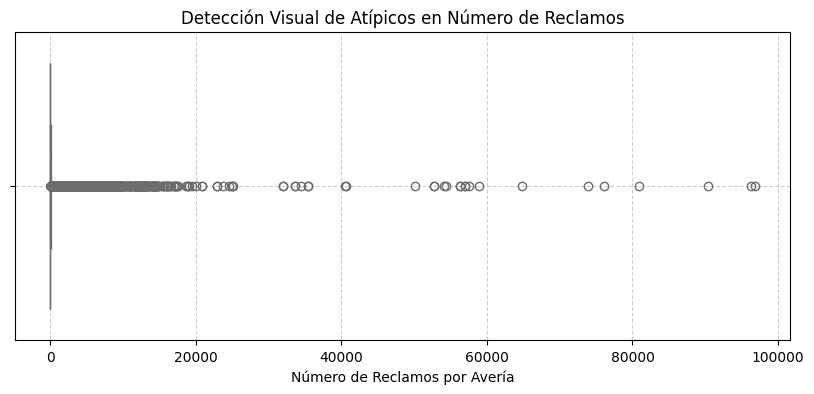

In [ ]:
print("==================================================")
print("               2. CALIDAD DE LOS DATOS            ")
print("==================================================\n")

# --- 2.1 Valores Faltantes ---
print("--- ANÁLISIS DE VALORES FALTANTES (NULOS) ---")
valores_nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
tabla_nulos = pd.DataFrame({'Nulos': valores_nulos, 'Porcentaje (%)': porcentaje_nulos})
print(tabla_nulos[tabla_nulos['Nulos'] > 0] if valores_nulos.sum() > 0 else "¡Excelente! No hay valores faltantes.")
print("-" * 50)

# --- 2.2 Valores Atípicos (Outliers) en Reclamos ---
print("--- ANÁLISIS DE VALORES ATÍPICOS (OUTLIERS) ---")
if 'Num_Reclamos_por_averia' in df.columns:
    # Método IQR (Rango Intercuartílico)
    Q1 = df['Num_Reclamos_por_averia'].quantile(0.25)
    Q3 = df['Num_Reclamos_por_averia'].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df['Num_Reclamos_por_averia'] < limite_inferior) | (df['Num_Reclamos_por_averia'] > limite_superior)]

    print(f"• Umbral superior para considerar Outlier: {limite_superior:.2f} reclamos")
    print(f"• Cantidad de registros atípicos detectados: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

    # Gráfico de Caja (Boxplot) para visualizar la dispersión y los outliers
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df['Num_Reclamos_por_averia'], color='salmon')
    plt.title('Detección Visual de Atípicos en Número de Reclamos')
    plt.xlabel('Número de Reclamos por Avería')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("No se encontró la columna numérica para calcular atípicos.")

### 2.3 Tratamiento de Valores Atípicos (Outliers)

--- TRATAMIENTO DE VALORES ATÍPICOS (CAPPING) ---
• Valores atípicos se limitarán: [-59.50, 104.50]
Outliers en 'Num_Reclamos_por_averia' han sido tratados mediante capping.


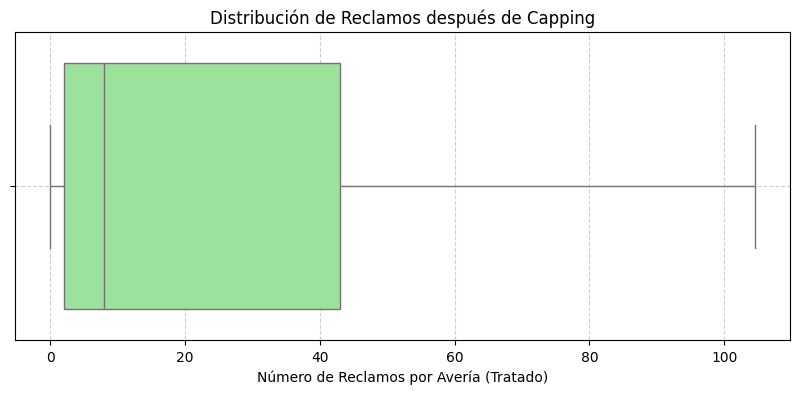

In [ ]:
print("--- TRATAMIENTO DE VALORES ATÍPICOS (CAPPING) ---")

if 'Num_Reclamos_por_averia' in df.columns:
    # Recalculamos Q1, Q3, IQR y límites por si el DataFrame ha cambiado
    Q1 = df['Num_Reclamos_por_averia'].quantile(0.25)
    Q3 = df['Num_Reclamos_por_averia'].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"• Valores atípicos se limitarán: [{limite_inferior:.2f}, {limite_superior:.2f}]")

    # Aplicar capping (winsorización)
    df['Num_Reclamos_por_averia'] = np.where(
        df['Num_Reclamos_por_averia'] < limite_inferior,
        limite_inferior,
        df['Num_Reclamos_por_averia']
    )
    df['Num_Reclamos_por_averia'] = np.where(
        df['Num_Reclamos_por_averia'] > limite_superior,
        limite_superior,
        df['Num_Reclamos_por_averia']
    )

    print("Outliers en 'Num_Reclamos_por_averia' han sido tratados mediante capping.")

    # Verificar la distribución después del capping
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df['Num_Reclamos_por_averia'], color='lightgreen')
    plt.title('Distribución de Reclamos después de Capping')
    plt.xlabel('Número de Reclamos por Avería (Tratado)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("La columna 'Num_Reclamos_por_averia' no se encontró para el tratamiento de atípicos.")

In [ ]:
print(df['Num_Reclamos_por_averia'].skew())

1.1966279066134762


      3. ANÁLISIS EXPLORATORIO DE VARIABLES      



/tmp/ipykernel_1124/1925779951.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Empresa operadora', order=df['Empresa operadora'].value_counts().index[:10], palette='viridis')


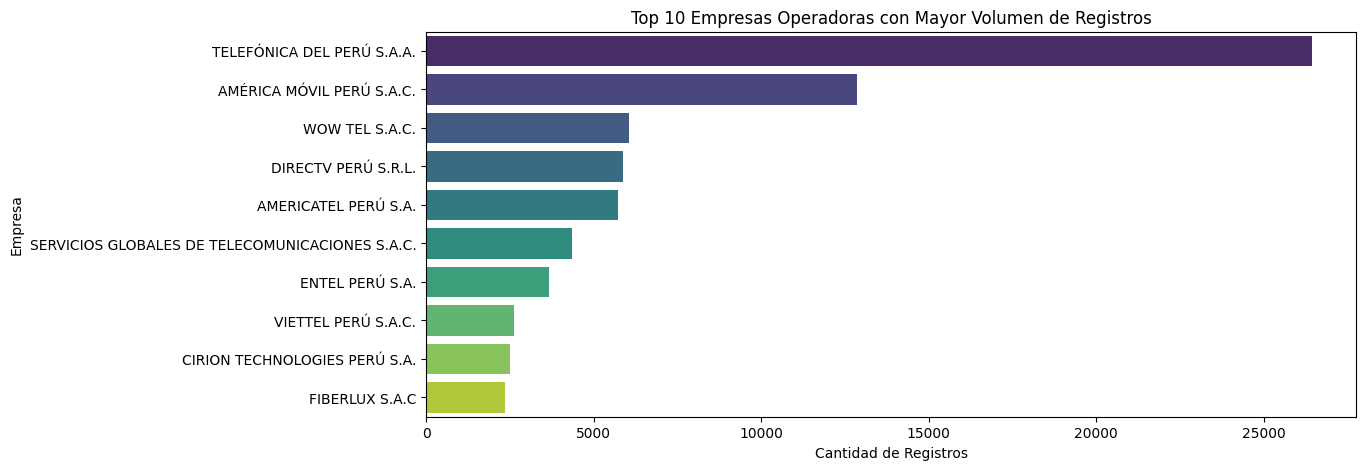

--- Análisis de Relaciones Clave ---

> Top 10 Empresas con más Reclamos Totales Acumulados:
Empresa operadora
TELEFÓNICA DEL PERÚ S.A.A.                         1293880.5
WOW TEL S.A.C.                                      259800.5
AMÉRICA MÓVIL PERÚ S.A.C.                           257290.0
DIRECTV PERÚ S.R.L.                                 200471.0
SERVICIOS GLOBALES DE TELECOMUNICACIONES S.A.C.     194139.5
INTEGRATEL PERÚ S.A.A.                              109720.5
AMERICATEL PERÚ S.A.                                 58439.0
TELEFÓNICA MULTIMEDIA S.A.C.                         54669.5
ENTEL PERÚ S.A.                                      41863.5
WI-NET TELECOM S.A.C.                                29753.5
Name: Num_Reclamos_por_averia, dtype: float64


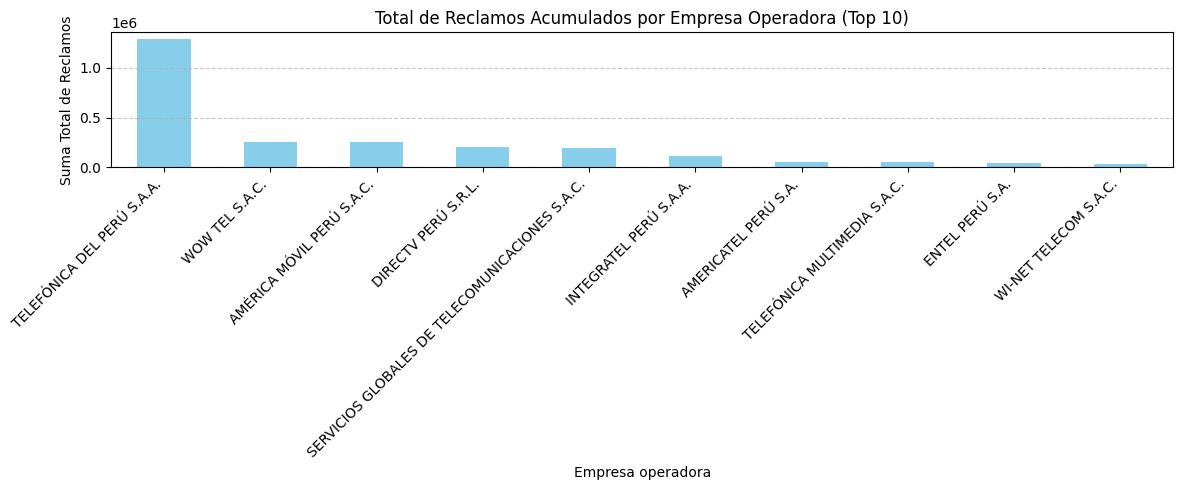

In [ ]:
print("==================================================")
print("      3. ANÁLISIS EXPLORATORIO DE VARIABLES      ")
print("==================================================\n")

# --- 3.1 Distribución de variables categóricas principales ---
plt.figure(figsize=(12, 5))
# Gráfico de las empresas operadoras con más registros
sns.countplot(data=df, y='Empresa operadora', order=df['Empresa operadora'].value_counts().index[:10], palette='viridis')
plt.title('Top 10 Empresas Operadoras con Mayor Volumen de Registros')
plt.xlabel('Cantidad de Registros')
plt.ylabel('Empresa')
plt.show()

# --- 3.2 Relaciones importantes entre variables ---
print("--- Análisis de Relaciones Clave ---")
# Agrupamos para ver qué empresa acumula la mayor cantidad real de reclamos acumulados
ranking_reclamos = df.groupby('Empresa operadora')['Num_Reclamos_por_averia'].sum().sort_values(ascending=False).head(10)
print("\n> Top 10 Empresas con más Reclamos Totales Acumulados:")
print(ranking_reclamos)

plt.figure(figsize=(12, 5))
ranking_reclamos.plot(kind='bar', color='skyblue')
plt.title('Total de Reclamos Acumulados por Empresa Operadora (Top 10)')
plt.ylabel('Suma Total de Reclamos')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Nota importante:

Ahora que hemos categorizado la `Resiliencia_Operativa` para el análisis descriptivo, ten en cuenta que el modelo que entrenamos (CatBoost y XGBoost) predice `Num_Reclamos_por_averia` (un valor numérico) y luego *derivamos* la `Resiliencia_Operativa` continua de esa predicción.

Si quisieras entrenar un modelo para *predecir directamente* esta `Resiliencia_Operativa_Category` (es decir, un problema de clasificación), tendrías que redefinir la variable objetivo de tus modelos y volver a ejecutar los pasos de preparación de datos (`df_encoded`, `X_train`, `X_test`) y el entrenamiento de los modelos para clasificación.

### Checking for Missing Values

In [ ]:
print("Missing values before handling:")
display(df.isnull().sum())

Missing values before handling:


,0
Empresa operadora,0
Mes,0
Departamento,0
Servicio involucrado,0
Materia reclamable,0
Tipo de reclamo,0
Num_Reclamos_por_averia,6


### Handle Missing Values and Duplicates

In [ ]:
# Eliminar filas con valores faltantes en «Num_Reclamos_por_averia»
df.dropna(subset=['Num_Reclamos_por_averia'], inplace=True)

print("Missing values after handling:")
display(df.isnull().sum())

# Buscar filas duplicadas
duplicates_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates_count}")

if duplicates_count > 0:
    print("Dropping duplicate rows...")
    df.drop_duplicates(inplace=True)
    print(f"Number of rows after dropping duplicates: {len(df)}")
else:
    print("No duplicate rows found.")

Missing values after handling:


,0
Empresa operadora,0
Mes,0
Departamento,0
Servicio involucrado,0
Materia reclamable,0
Tipo de reclamo,0
Num_Reclamos_por_averia,0



Number of duplicate rows: 1507
Dropping duplicate rows...
Number of rows after dropping duplicates: 102948


### Distribution Analysis of Key Features

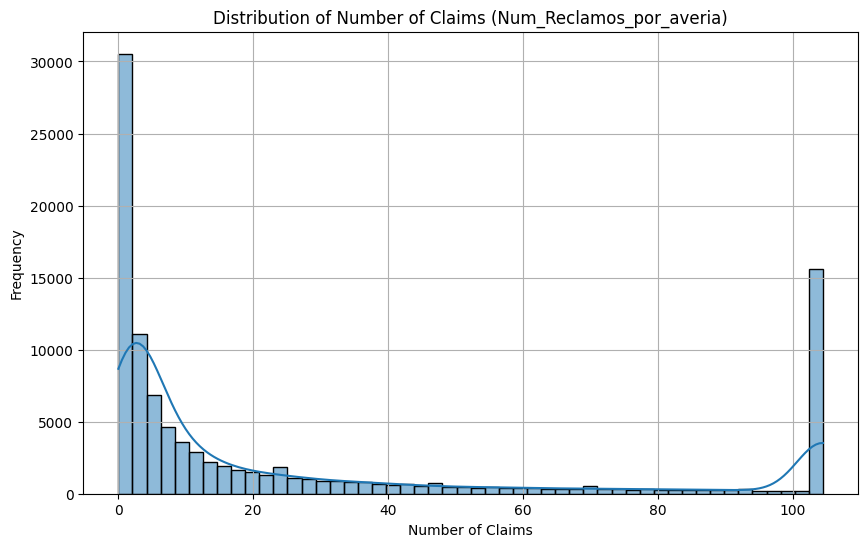

/tmp/ipykernel_1124/186093759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


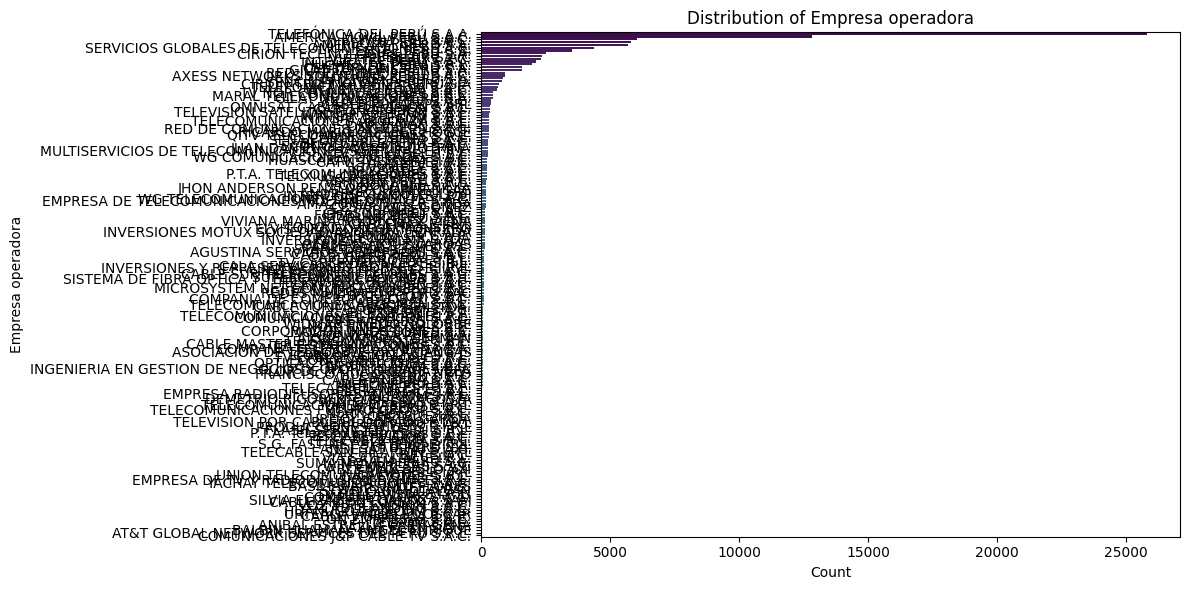

/tmp/ipykernel_1124/186093759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


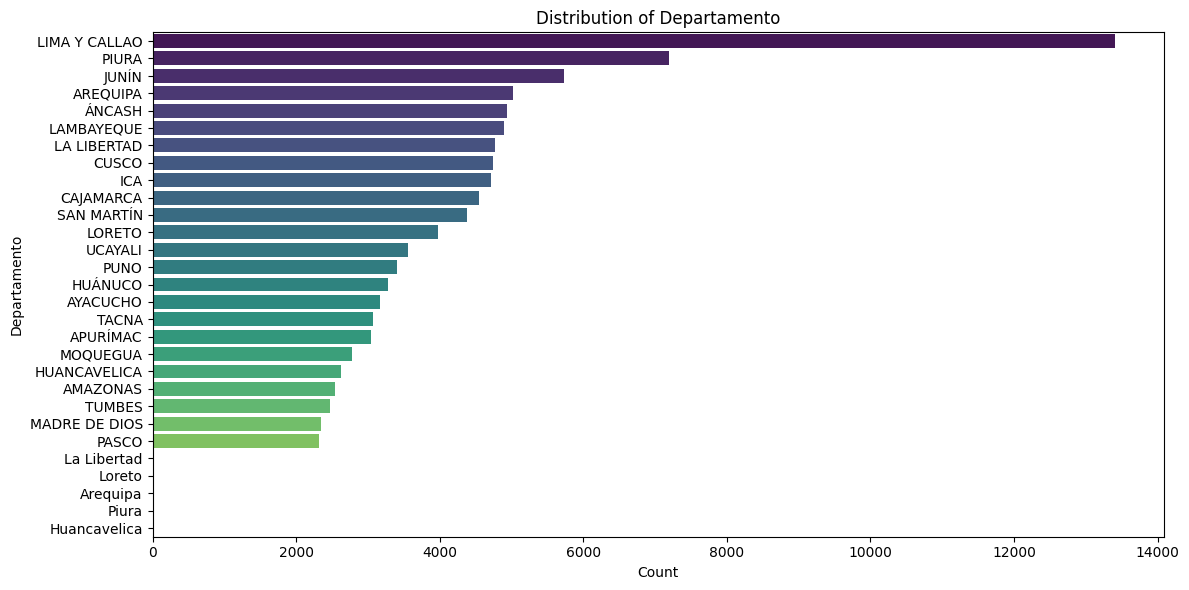

/tmp/ipykernel_1124/186093759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


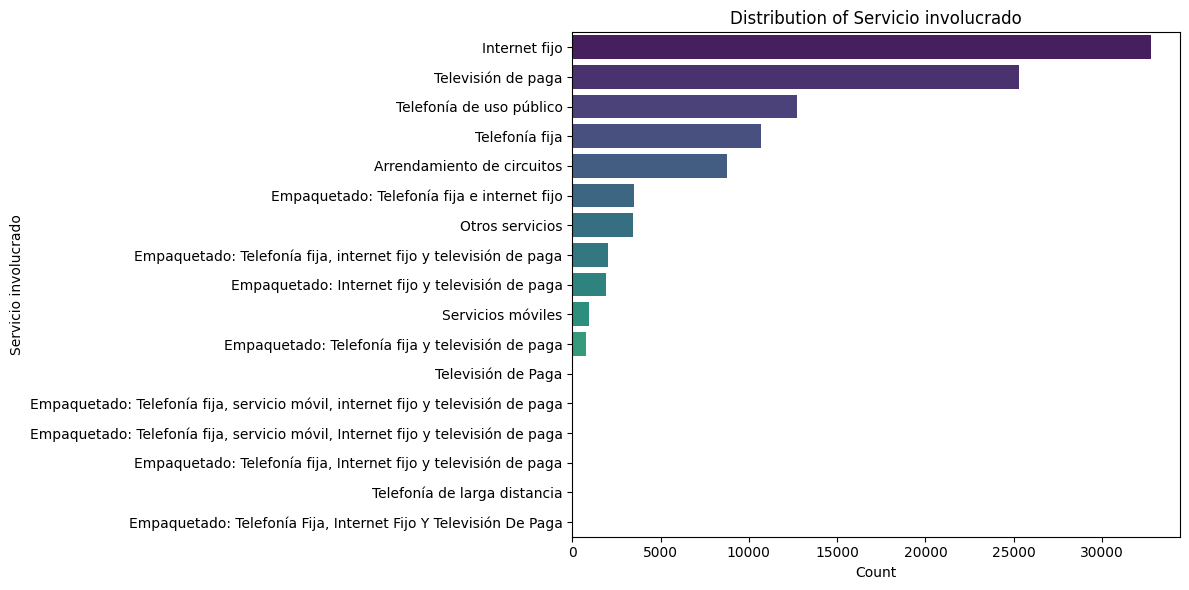

/tmp/ipykernel_1124/186093759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


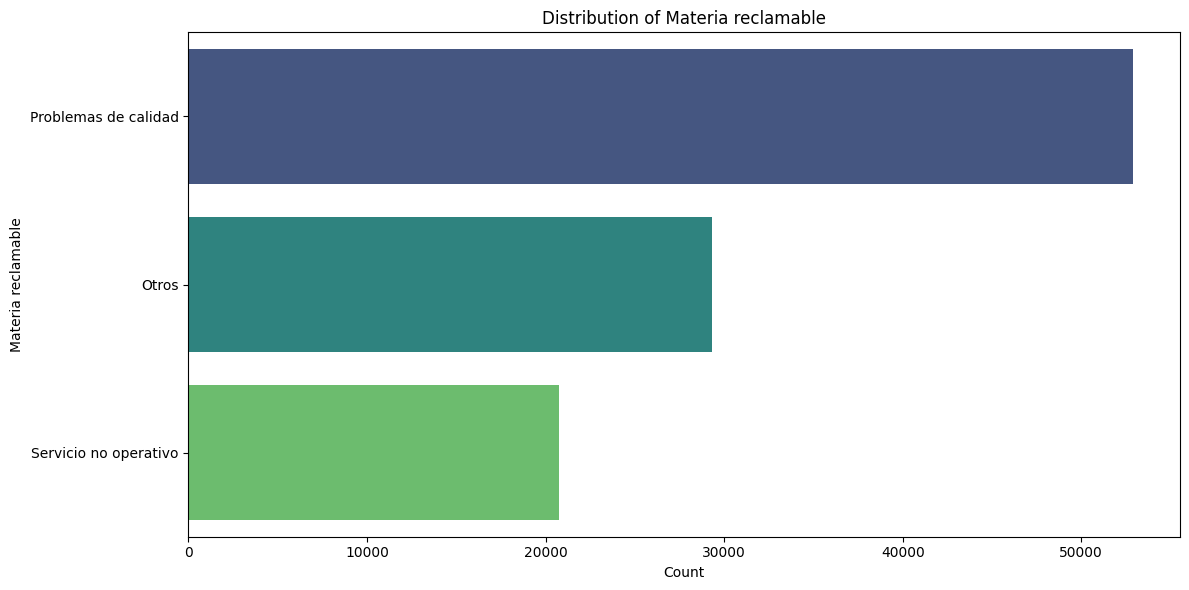

/tmp/ipykernel_1124/186093759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


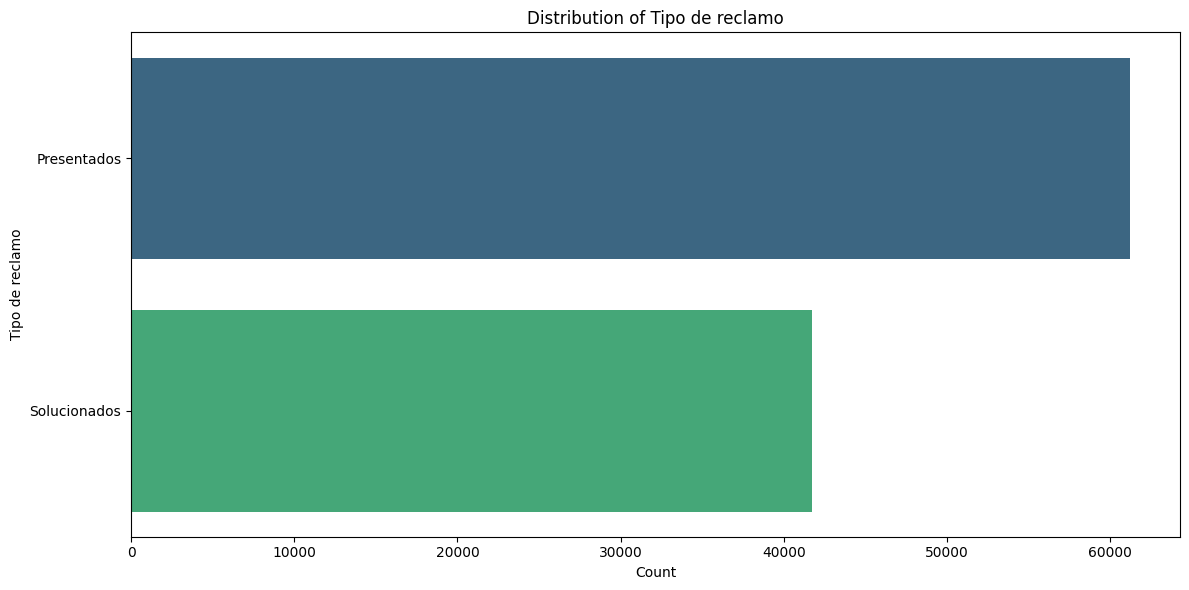

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Num_Reclamos_por_averia'], bins=50, kde=True)
plt.title('Distribution of Number of Claims (Num_Reclamos_por_averia)')
plt.xlabel('Number of Claims')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Analizar características categóricas
categorical_cols = ['Empresa operadora', 'Departamento', 'Servicio involucrado', 'Materia reclamable', 'Tipo de reclamo']

for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Time-Series Analysis: Extracting Time Features and Visualizing Trends

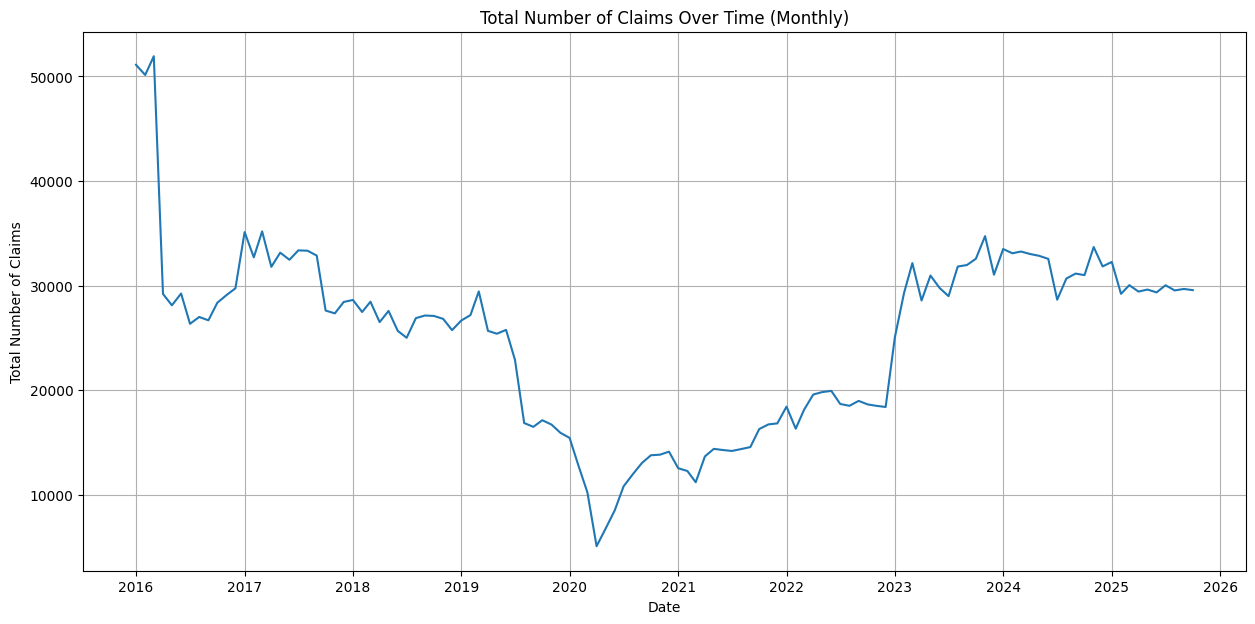

/tmp/ipykernel_1124/2287190509.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_claims, x='Year', y='Num_Reclamos_por_averia', palette='viridis')


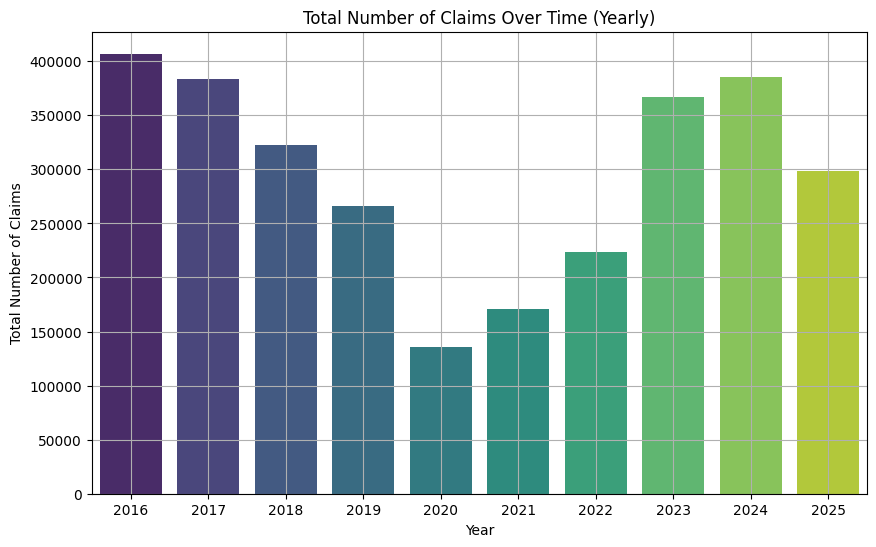

In [ ]:
# Extraer el año y el mes de «Mes»
df['Year'] = df['Mes'].dt.year
df['Month'] = df['Mes'].dt.month

# Agrupa por mes y año para ver las tendencias
monthly_claims = df.groupby(['Year', 'Month'])['Num_Reclamos_por_averia'].sum().reset_index()
monthly_claims['Date'] = pd.to_datetime(monthly_claims['Year'].astype(str) + '-' + monthly_claims['Month'].astype(str))

plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_claims, x='Date', y='Num_Reclamos_por_averia')
plt.title('Total Number of Claims Over Time (Monthly)')
plt.xlabel('Date')
plt.ylabel('Total Number of Claims')
plt.grid(True)
plt.show()

# Agrupa por año para ver las tendencias anuales
yearly_claims = df.groupby('Year')['Num_Reclamos_por_averia'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=yearly_claims, x='Year', y='Num_Reclamos_por_averia', palette='viridis')
plt.title('Total Number of Claims Over Time (Yearly)')
plt.xlabel('Year')
plt.ylabel('Total Number of Claims')
plt.grid(True)
plt.show()

### Correlation Analysis (if applicable) and Feature Engineering Prep

In [ ]:
print("Updated DataFrame head with new time features:")
display(df.head())

print("\nDataFrame Information after adding time features:")
df.info()

Updated DataFrame head with new time features:


,Empresa operadora,Mes,Departamento,Servicio involucrado,Materia reclamable,Tipo de reclamo,Num_Reclamos_por_averia,Year,Month
0,AMÉRICA MÓVIL PERÚ S.A.C.,2016-01-01,ICA,Arrendamiento de circuitos,Problemas de calidad,Presentados,1.0,2016,1
1,AMÉRICA MÓVIL PERÚ S.A.C.,2016-01-01,LA LIBERTAD,Arrendamiento de circuitos,Problemas de calidad,Presentados,1.0,2016,1
2,AMÉRICA MÓVIL PERÚ S.A.C.,2016-01-01,PIURA,Arrendamiento de circuitos,Problemas de calidad,Presentados,1.0,2016,1
3,AMÉRICA MÓVIL PERÚ S.A.C.,2016-01-01,CUSCO,Arrendamiento de circuitos,Otros,Solucionados,1.0,2016,1
4,AMÉRICA MÓVIL PERÚ S.A.C.,2016-01-01,LA LIBERTAD,Arrendamiento de circuitos,Otros,Solucionados,1.0,2016,1



DataFrame Information after adding time features:
<class 'pandas.core.frame.DataFrame'>
Index: 102948 entries, 0 to 104460
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Empresa operadora        102948 non-null  object        
 1   Mes                      102948 non-null  datetime64[ns]
 2   Departamento             102948 non-null  object        
 3   Servicio involucrado     102948 non-null  object        
 4   Materia reclamable       102948 non-null  object        
 5   Tipo de reclamo          102948 non-null  object        
 6   Num_Reclamos_por_averia  102948 non-null  float64       
 7   Year                     102948 non-null  int32         
 8   Month                    102948 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(2), object(5)
memory usage: 7.1+ MB


### Aggregation Level Review: Mes + Empresa Operadora + Departamento

As requested, the model will now operate on an aggregated dataset to explore different levels of predictive capacity. We will aggregate by `Mes`, `Empresa operadora`, and `Departamento`, summing the `Num_Reclamos_por_averia`.

In [ ]:
# Agregar datos por Mes, Empresa operadora y Departamento
df_agg = df.groupby(['Mes', 'Empresa operadora', 'Departamento', 'Servicio involucrado', 'Materia reclamable', 'Tipo de reclamo'])['Num_Reclamos_por_averia'].sum().reset_index()

# Cambia el nombre de la columna «sum» para mayor claridad
df_agg.rename(columns={'Num_Reclamos_por_averia': 'Num_Reclamos_por_averia_Aggregated'}, inplace=True)

print("Aggregated DataFrame head:")
display(df_agg.head())

print("Aggregated DataFrame Information:")
df_agg.info()

Aggregated DataFrame head:


,Mes,Empresa operadora,Departamento,Servicio involucrado,Materia reclamable,Tipo de reclamo,Num_Reclamos_por_averia_Aggregated
0,2016-01-01,A & P SERVITEL S.A.C.,JUNÍN,Televisión de paga,Otros,Presentados,3.0
1,2016-01-01,A & P SERVITEL S.A.C.,JUNÍN,Televisión de paga,Otros,Solucionados,8.0
2,2016-01-01,A & P SERVITEL S.A.C.,JUNÍN,Televisión de paga,Problemas de calidad,Presentados,5.0
3,2016-01-01,AGUSTINA SERVICIOS GENERALES S.A.C.,LA LIBERTAD,Internet fijo,Problemas de calidad,Presentados,6.0
4,2016-01-01,AGUSTINA SERVICIOS GENERALES S.A.C.,LA LIBERTAD,Internet fijo,Servicio no operativo,Presentados,2.0


Aggregated DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100247 entries, 0 to 100246
Data columns (total 7 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   Mes                                 100247 non-null  datetime64[ns]
 1   Empresa operadora                   100247 non-null  object        
 2   Departamento                        100247 non-null  object        
 3   Servicio involucrado                100247 non-null  object        
 4   Materia reclamable                  100247 non-null  object        
 5   Tipo de reclamo                     100247 non-null  object        
 6   Num_Reclamos_por_averia_Aggregated  100247 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 5.4+ MB


### Feature Engineering: Temporal Variables (Year, Month, Quarter, Semester)

In [ ]:
# Extraer características temporales de «Mes» en el DataFrame agregado
df_agg['Year'] = df_agg['Mes'].dt.year
df_agg['Month'] = df_agg['Mes'].dt.month
df_agg['Quarter'] = df_agg['Mes'].dt.quarter
df_agg['Semester'] = (df_agg['Mes'].dt.month - 1) // 6 + 1

print("Aggregated DataFrame head with new temporal features:")
display(df_agg.head())

print("Aggregated DataFrame Information after adding temporal features:")
df_agg.info()

Aggregated DataFrame head with new temporal features:


,Mes,Empresa operadora,Departamento,Servicio involucrado,Materia reclamable,Tipo de reclamo,Num_Reclamos_por_averia_Aggregated,Year,Month,Quarter,Semester
0,2016-01-01,A & P SERVITEL S.A.C.,JUNÍN,Televisión de paga,Otros,Presentados,3.0,2016,1,1,1
1,2016-01-01,A & P SERVITEL S.A.C.,JUNÍN,Televisión de paga,Otros,Solucionados,8.0,2016,1,1,1
2,2016-01-01,A & P SERVITEL S.A.C.,JUNÍN,Televisión de paga,Problemas de calidad,Presentados,5.0,2016,1,1,1
3,2016-01-01,AGUSTINA SERVICIOS GENERALES S.A.C.,LA LIBERTAD,Internet fijo,Problemas de calidad,Presentados,6.0,2016,1,1,1
4,2016-01-01,AGUSTINA SERVICIOS GENERALES S.A.C.,LA LIBERTAD,Internet fijo,Servicio no operativo,Presentados,2.0,2016,1,1,1


Aggregated DataFrame Information after adding temporal features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100247 entries, 0 to 100246
Data columns (total 11 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   Mes                                 100247 non-null  datetime64[ns]
 1   Empresa operadora                   100247 non-null  object        
 2   Departamento                        100247 non-null  object        
 3   Servicio involucrado                100247 non-null  object        
 4   Materia reclamable                  100247 non-null  object        
 5   Tipo de reclamo                     100247 non-null  object        
 6   Num_Reclamos_por_averia_Aggregated  100247 non-null  float64       
 7   Year                                100247 non-null  int32         
 8   Month                               100247 non-null  int32         
 9   Quarter         

### Re-calculating Resiliencia Operativa on Aggregated Data

In [ ]:
# Volver a calcular «Resiliencia_Operativa» sobre los datos agregados
df_agg['Resiliencia_Operativa'] = 1 / (1 + df_agg['Num_Reclamos_por_averia_Aggregated'])

# Volver a calcular la variable categórica «Resiliencia_Operativa»
p33_ro_agg = df_agg['Resiliencia_Operativa'].quantile(0.33)
p66_ro_agg = df_agg['Resiliencia_Operativa'].quantile(0.66)

conditions_agg = [
    df_agg['Resiliencia_Operativa'] <= p33_ro_agg,
    (df_agg['Resiliencia_Operativa'] > p33_ro_agg) & (df_agg['Resiliencia_Operativa'] <= p66_ro_agg),
    df_agg['Resiliencia_Operativa'] > p66_ro_agg
]
choices_agg = ['Baja', 'Media', 'Alta']
df_agg['Resiliencia_Operativa_Category'] = np.select(conditions_agg, choices_agg, default='Baja')

print("Aggregated DataFrame head with re-calculated Resiliencia_Operativa:")
display(df_agg[['Num_Reclamos_por_averia_Aggregated', 'Resiliencia_Operativa', 'Resiliencia_Operativa_Category']].head())

Aggregated DataFrame head with re-calculated Resiliencia_Operativa:


,Num_Reclamos_por_averia_Aggregated,Resiliencia_Operativa,Resiliencia_Operativa_Category
0,3.0,0.250000,Media
1,8.0,0.111111,Media
2,5.0,0.166667,Media
3,6.0,0.142857,Media
4,2.0,0.333333,Alta


### Feature Engineering: Handling High-Cardinality Categorical Features (Empresa operadora) on Aggregated Data

Re-applying the grouping for `Empresa operadora` on the aggregated dataframe.

In [ ]:
# Analizar la cardinalidad de «Empresa operadora» en df_agg
print(f"Number of unique 'Empresa operadora' (aggregated): {df_agg['Empresa operadora'].nunique()}")

# Agrupar la categoría poco frecuente «Empresa operadora» en «Otros»
top_n = 20
top_operators_agg = df_agg['Empresa operadora'].value_counts().nlargest(top_n).index
df_agg['Empresa_operadora_grouped'] = df_agg['Empresa operadora'].apply(lambda x: x if x in top_operators_agg else 'Other')

print("\nValue counts for 'Empresa_operadora_grouped' (aggregated):")
display(df_agg['Empresa_operadora_grouped'].value_counts())

# Eliminar la columna original «Empresa operadora»
df_agg.drop(columns=['Empresa operadora'], inplace=True)

print("\nAggregated DataFrame head after grouping 'Empresa operadora':")
display(df_agg.head())

Number of unique 'Empresa operadora' (aggregated): 181

Value counts for 'Empresa_operadora_grouped' (aggregated):


,count
Empresa_operadora_grouped,
TELEFÓNICA DEL PERÚ S.A.A.,25062
Other,19155
AMÉRICA MÓVIL PERÚ S.A.C.,12473
WOW TEL S.A.C.,6008
DIRECTV PERÚ S.R.L.,5702
AMERICATEL PERÚ S.A.,5573
SERVICIOS GLOBALES DE TELECOMUNICACIONES S.A.C.,4370
ENTEL PERÚ S.A.,3258
CIRION TECHNOLOGIES PERÚ S.A.,2369



Aggregated DataFrame head after grouping 'Empresa operadora':


,Mes,Departamento,Servicio involucrado,Materia reclamable,Tipo de reclamo,Num_Reclamos_por_averia_Aggregated,Year,Month,Quarter,Semester,Resiliencia_Operativa,Resiliencia_Operativa_Category,Empresa_operadora_grouped
0,2016-01-01,JUNÍN,Televisión de paga,Otros,Presentados,3.0,2016,1,1,1,0.250000,Media,Other
1,2016-01-01,JUNÍN,Televisión de paga,Otros,Solucionados,8.0,2016,1,1,1,0.111111,Media,Other
2,2016-01-01,JUNÍN,Televisión de paga,Problemas de calidad,Presentados,5.0,2016,1,1,1,0.166667,Media,Other
3,2016-01-01,LA LIBERTAD,Internet fijo,Problemas de calidad,Presentados,6.0,2016,1,1,1,0.142857,Media,Other
4,2016-01-01,LA LIBERTAD,Internet fijo,Servicio no operativo,Presentados,2.0,2016,1,1,1,0.333333,Alta,Other


### Feature Engineering: One-Hot Encoding for Remaining Categorical Features

In [ ]:
import pandas as pd
import numpy as np

print("\n### FASE 3: REVISIÓN DEL NIVEL DE AGREGACIÓN & FASE 4-5: VARIABLES TEMPORALES Y FEATURE ENGINEERING")

# --- 3. Revisión del Nivel de Agregación: Mes + Empresa + Departamento + Servicio + Materia + Tipo ---
# Agregamos los datos por las dimensiones clave y sumamos el número de reclamos
df_agg = df.groupby(['Mes', 'Empresa operadora', 'Departamento', 'Servicio involucrado', 'Materia reclamable', 'Tipo de reclamo'])['Num_Reclamos_por_averia'].sum().reset_index()
df_agg.rename(columns={'Num_Reclamos_por_averia': 'Num_Reclamos_por_averia_Aggregated'}, inplace=True)
print("\nAggregated DataFrame head (Mes + Empresa + Departamento + Servicio + Materia + Tipo):")
display(df_agg.head())

# --- 4. Variables Temporales: Year, Month, Quarter, Semester ---
# Extraemos características temporales de la columna 'Mes'
df_agg['Year'] = df_agg['Mes'].dt.year
df_agg['Month'] = df_agg['Mes'].dt.month
df_agg['Quarter'] = df_agg['Mes'].dt.quarter
df_agg['Semester'] = (df_agg['Mes'].dt.month - 1) // 6 + 1
print("\nAggregated DataFrame head with new temporal features:")
display(df_agg.head())

# --- Re-calculando Resiliencia Operativa en Datos Agregados ---
# Re-calculamos Resiliencia_Operativa y su categoría en los datos agregados
df_agg['Resiliencia_Operativa'] = 1 / (1 + df_agg['Num_Reclamos_por_averia_Aggregated'])
p33_ro_agg = df_agg['Resiliencia_Operativa'].quantile(0.33)
p66_ro_agg = df_agg['Resiliencia_Operativa'].quantile(0.66)
conditions_agg = [
    df_agg['Resiliencia_Operativa'] <= p33_ro_agg,
    (df_agg['Resiliencia_Operativa'] > p33_ro_agg) & (df_agg['Resiliencia_Operativa'] <= p66_ro_agg),
    df_agg['Resiliencia_Operativa'] > p66_ro_agg
]
choices_agg = ['Baja', 'Media', 'Alta']
df_agg['Resiliencia_Operativa_Category'] = np.select(conditions_agg, choices_agg, default='Baja')
print("\nAggregated DataFrame head with re-calculated Resiliencia_Operativa:")
display(df_agg[['Num_Reclamos_por_averia_Aggregated', 'Resiliencia_Operativa', 'Resiliencia_Operativa_Category']].head())

# --- Feature Engineering: Handling High-Cardinality Categorical Features (Empresa operadora) on Aggregated Data ---
top_n = 20
top_operators_agg = df_agg['Empresa operadora'].value_counts().nlargest(top_n).index
df_agg['Empresa_operadora_grouped'] = df_agg['Empresa operadora'].apply(lambda x: x if x in top_operators_agg else 'Other')
df_agg.drop(columns=['Empresa operadora'], inplace=True) # Drop the original
print("\nAggregated DataFrame head after grouping 'Empresa operadora':")
display(df_agg.head())

# --- FASE 6: CATEGÓRICAS NATIVAS para CatBoost ---
# Para CatBoost, convertimos las columnas categóricas a tipo 'category'
categorical_cols_native = [
    'Departamento',
    'Servicio involucrado',
    'Materia reclamable',
    'Tipo de reclamo',
    'Empresa_operadora_grouped'
]
for col in categorical_cols_native:
    if col in df_agg.columns:
        df_agg[col] = df_agg[col].astype('category')

# Se descarta la columna original 'Mes' ya que hemos extraído características temporales de ella.
df_agg.drop(columns=['Mes'], inplace=True)

# El DataFrame preparado para el modelado (con categoricals nativos) es df_agg
df_prepared = df_agg.copy()

print("\nDataFrame final preparado para el modelado (df_prepared):")
display(df_prepared.head())
df_prepared.info()


### FASE 3: REVISIÓN DEL NIVEL DE AGREGACIÓN & FASE 4-5: VARIABLES TEMPORALES Y FEATURE ENGINEERING

Aggregated DataFrame head (Mes + Empresa + Departamento + Servicio + Materia + Tipo):


,Mes,Empresa operadora,Departamento,Servicio involucrado,Materia reclamable,Tipo de reclamo,Num_Reclamos_por_averia_Aggregated
0,2016-01-01,A & P SERVITEL S.A.C.,JUNÍN,Televisión de paga,Otros,Presentados,3.0
1,2016-01-01,A & P SERVITEL S.A.C.,JUNÍN,Televisión de paga,Otros,Solucionados,8.0
2,2016-01-01,A & P SERVITEL S.A.C.,JUNÍN,Televisión de paga,Problemas de calidad,Presentados,5.0
3,2016-01-01,AGUSTINA SERVICIOS GENERALES S.A.C.,LA LIBERTAD,Internet fijo,Problemas de calidad,Presentados,6.0
4,2016-01-01,AGUSTINA SERVICIOS GENERALES S.A.C.,LA LIBERTAD,Internet fijo,Servicio no operativo,Presentados,2.0



Aggregated DataFrame head with new temporal features:


,Mes,Empresa operadora,Departamento,Servicio involucrado,Materia reclamable,Tipo de reclamo,Num_Reclamos_por_averia_Aggregated,Year,Month,Quarter,Semester
0,2016-01-01,A & P SERVITEL S.A.C.,JUNÍN,Televisión de paga,Otros,Presentados,3.0,2016,1,1,1
1,2016-01-01,A & P SERVITEL S.A.C.,JUNÍN,Televisión de paga,Otros,Solucionados,8.0,2016,1,1,1
2,2016-01-01,A & P SERVITEL S.A.C.,JUNÍN,Televisión de paga,Problemas de calidad,Presentados,5.0,2016,1,1,1
3,2016-01-01,AGUSTINA SERVICIOS GENERALES S.A.C.,LA LIBERTAD,Internet fijo,Problemas de calidad,Presentados,6.0,2016,1,1,1
4,2016-01-01,AGUSTINA SERVICIOS GENERALES S.A.C.,LA LIBERTAD,Internet fijo,Servicio no operativo,Presentados,2.0,2016,1,1,1



Aggregated DataFrame head with re-calculated Resiliencia_Operativa:


...


Aggregated DataFrame head after grouping 'Empresa operadora':


,Mes,Departamento,Servicio involucrado,Materia reclamable,Tipo de reclamo,Num_Reclamos_por_averia_Aggregated,Year,Month,Quarter,Semester,Resiliencia_Operativa,Resiliencia_Operativa_Category,Empresa_operadora_grouped
0,2016-01-01,JUNÍN,Televisión de paga,Otros,Presentados,3.0,2016,1,1,1,0.250000,Media,Other
1,2016-01-01,JUNÍN,Televisión de paga,Otros,Solucionados,8.0,2016,1,1,1,0.111111,Media,Other
2,2016-01-01,JUNÍN,Televisión de paga,Problemas de calidad,Presentados,5.0,2016,1,1,1,0.166667,Media,Other
3,2016-01-01,LA LIBERTAD,Internet fijo,Problemas de calidad,Presentados,6.0,2016,1,1,1,0.142857,Media,Other
4,2016-01-01,LA LIBERTAD,Internet fijo,Servicio no operativo,Presentados,2.0,2016,1,1,1,0.333333,Alta,Other



DataFrame final preparado para el modelado (df_prepared):


,Departamento,Servicio involucrado,Materia reclamable,Tipo de reclamo,Num_Reclamos_por_averia_Aggregated,Year,Month,Quarter,Semester,Resiliencia_Operativa,Resiliencia_Operativa_Category,Empresa_operadora_grouped
0,JUNÍN,Televisión de paga,Otros,Presentados,3.0,2016,1,1,1,0.250000,Media,Other
1,JUNÍN,Televisión de paga,Otros,Solucionados,8.0,2016,1,1,1,0.111111,Media,Other
2,JUNÍN,Televisión de paga,Problemas de calidad,Presentados,5.0,2016,1,1,1,0.166667,Media,Other
3,LA LIBERTAD,Internet fijo,Problemas de calidad,Presentados,6.0,2016,1,1,1,0.142857,Media,Other
4,LA LIBERTAD,Internet fijo,Servicio no operativo,Presentados,2.0,2016,1,1,1,0.333333,Alta,Other


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100247 entries, 0 to 100246
Data columns (total 12 columns):
 #   Column                              Non-Null Count   Dtype   
---  ------                              --------------   -----   
 0   Departamento                        100247 non-null  category
 1   Servicio involucrado                100247 non-null  category
 2   Materia reclamable                  100247 non-null  category
 3   Tipo de reclamo                     100247 non-null  category
 4   Num_Reclamos_por_averia_Aggregated  100247 non-null  float64 
 5   Year                                100247 non-null  int32   
 6   Month                               100247 non-null  int32   
 7   Quarter                             100247 non-null  int32   
 8   Semester                            100247 non-null  int32   
 9   Resiliencia_Operativa               100247 non-null  float64 
 10  Resiliencia_Operativa_Category      100247 non-null  object  
 11  Empresa_opera

In [ ]:
# En el caso de modelos como CatBoost, que gestionan características categóricas de forma nativa, las convertiremos al tipo de datos «category».
# Para otros modelos que requieran codificación one-hot, este paso se ajustaría o se llevaría a cabo más adelante.

# Identificar las columnas categóricas restantes tras la agrupación
categorical_cols_native = [
    'Departamento',
    'Servicio involucrado',
    'Materia reclamable',
    'Tipo de reclamo',
    'Empresa_operadora_grouped'
]

# Convertir las columnas categóricas identificadas al tipo de datos «category»
for col in categorical_cols_native:
    if col in df_agg.columns:
        df_agg[col] = df_agg[col].astype('category')

# La columna original «Mes» ya se había eliminado en la celda d111b48e tras extraer las características temporales.
# df_agg.drop(columns=['Mes'], inplace=True) # Esta línea provocó el error KeyError, ya que «Mes» ya se había eliminado.

# El marco de datos que se utilizará para el modelado será ahora df_agg, que contiene variables categóricas nativas y características agregadas.
df_prepared = df_agg.copy()

print("\nDataFrame head after preparing categorical features for native handling:")
display(df_prepared.head())

print("\nDataFrame Information after preparing categorical features:")
df_prepared.info()


DataFrame head after preparing categorical features for native handling:


,Departamento,Servicio involucrado,Materia reclamable,Tipo de reclamo,Num_Reclamos_por_averia_Aggregated,Year,Month,Quarter,Semester,Resiliencia_Operativa,Resiliencia_Operativa_Category,Empresa_operadora_grouped
0,JUNÍN,Televisión de paga,Otros,Presentados,3.0,2016,1,1,1,0.250000,Media,Other
1,JUNÍN,Televisión de paga,Otros,Solucionados,8.0,2016,1,1,1,0.111111,Media,Other
2,JUNÍN,Televisión de paga,Problemas de calidad,Presentados,5.0,2016,1,1,1,0.166667,Media,Other
3,LA LIBERTAD,Internet fijo,Problemas de calidad,Presentados,6.0,2016,1,1,1,0.142857,Media,Other
4,LA LIBERTAD,Internet fijo,Servicio no operativo,Presentados,2.0,2016,1,1,1,0.333333,Alta,Other



DataFrame Information after preparing categorical features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100247 entries, 0 to 100246
Data columns (total 12 columns):
 #   Column                              Non-Null Count   Dtype   
---  ------                              --------------   -----   
 0   Departamento                        100247 non-null  category
 1   Servicio involucrado                100247 non-null  category
 2   Materia reclamable                  100247 non-null  category
 3   Tipo de reclamo                     100247 non-null  category
 4   Num_Reclamos_por_averia_Aggregated  100247 non-null  float64 
 5   Year                                100247 non-null  int32   
 6   Month                               100247 non-null  int32   
 7   Quarter                             100247 non-null  int32   
 8   Semester                            100247 non-null  int32   
 9   Resiliencia_Operativa               100247 non-null  float64 
 10  Resiliencia_Operati

## 3. Model Building and Evaluation

### Data Splitting: Time-based Split

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd

print("\n### FASE 2: VALIDACIÓN TEMPORAL (Train, Validation, Test Split)")

# Ordenar el DataFrame por 'Year' y 'Month' para asegurar la secuencia temporal
df_sorted = df_prepared.sort_values(by=['Year', 'Month']).reset_index(drop=True)

# Definir características (X) y variable objetivo (y)
X = df_sorted.drop(['Num_Reclamos_por_averia_Aggregated', 'Resiliencia_Operativa', 'Resiliencia_Operativa_Category'], axis=1)
y = df_sorted['Num_Reclamos_por_averia_Aggregated']

print(f"Original df_sorted shape: {df_sorted.shape}")
print(f"X shape after dropping target and derived columns: {X.shape}")
print(f"y shape: {y.shape}")

# Determinar los puntos de división para Train, Validation y Test (70%, 15%, 15%)
train_split_point = int(len(X) * 0.7)
val_split_point = int(len(X) * 0.85) # 70% train, 15% validation, 15% test

X_train = X.iloc[:train_split_point]
y_train = y.iloc[:train_split_point]

X_val = X.iloc[train_split_point:val_split_point]
y_val = y.iloc[train_split_point:val_split_point]

X_test = X.iloc[val_split_point:]
y_test = y.iloc[val_split_point:]

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

print(f"\nTraining data time range: {df_sorted['Year'].iloc[0]}-{df_sorted['Month'].iloc[0]} to {df_sorted['Year'].iloc[train_split_point-1]}-{df_sorted['Month'].iloc[train_split_point-1]}")
print(f"Validation data time range: {df_sorted['Year'].iloc[train_split_point]}-{df_sorted['Month'].iloc[train_split_point]} to {df_sorted['Year'].iloc[val_split_point-1]}-{df_sorted['Month'].iloc[val_split_point-1]}")
print(f"Test data time range: {df_sorted['Year'].iloc[val_split_point]}-{df_sorted['Month'].iloc[val_split_point]} to {df_sorted['Year'].iloc[-1]}-{df_sorted['Month'].iloc[-1]}")


### FASE 2: VALIDACIÓN TEMPORAL (Train, Validation, Test Split)
Original df_sorted shape: (100247, 12)
X shape after dropping target and derived columns: (100247, 9)
y shape: (100247,)

Shape of X_train: (70172, 9)
Shape of y_train: (70172,)
Shape of X_val: (15037, 9)
Shape of y_val: (15037,)
Shape of X_test: (15038, 9)
Shape of y_test: (15038,)

Training data time range: 2016-1 to 2023-5
Validation data time range: 2023-5 to 2024-8
Test data time range: 2024-8 to 2025-10


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

# Ordena los datos por «Año» y «Mes» para garantizar una división temporal
df_sorted = df_prepared.sort_values(by=['Year', 'Month']).reset_index(drop=True)

# Definir características (X) y objetivo (y)
X = df_sorted.drop(['Num_Reclamos_por_averia_Aggregated', 'Resiliencia_Operativa', 'Resiliencia_Operativa_Category'], axis=1)
y = df_sorted['Num_Reclamos_por_averia_Aggregated']

print(f"Original df_sorted shape: {df_sorted.shape}")
print(f"X shape after dropping target and derived columns: {X.shape}")
print(f"y shape: {y.shape}")

# Inicializar TimeSeriesSplit: por ahora, utilizaremos una división simple como primer paso.
# En pasos posteriores se implementará una validación cruzada adecuada con TimeSeriesSplit.

# Determinar el punto de división para los conjuntos de entrenamiento, validación y prueba (por ejemplo, 70 % de entrenamiento, 15 % de validación y 15 % de prueba)
train_split_point = int(len(X) * 0.7)
val_split_point = int(len(X) * 0.85) # 70 % de entrenamiento, 15 % de validación, 15 % de prueba

X_train = X.iloc[:train_split_point]
y_train = y.iloc[:train_split_point]

X_val = X.iloc[train_split_point:val_split_point]
y_val = y.iloc[train_split_point:val_split_point]

X_test = X.iloc[val_split_point:]
y_test = y.iloc[val_split_point:]

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

print(f"\nTraining data time range: {df_sorted['Year'].iloc[0]}-{df_sorted['Month'].iloc[0]} to {df_sorted['Year'].iloc[train_split_point-1]}-{df_sorted['Month'].iloc[train_split_point-1]}")
print(f"Validation data time range: {df_sorted['Year'].iloc[train_split_point]}-{df_sorted['Month'].iloc[train_split_point]} to {df_sorted['Year'].iloc[val_split_point-1]}-{df_sorted['Month'].iloc[val_split_point-1]}")
print(f"Test data time range: {df_sorted['Year'].iloc[val_split_point]}-{df_sorted['Month'].iloc[val_split_point]} to {df_sorted['Year'].iloc[-1]}-{df_sorted['Month'].iloc[-1]}")

Original df_sorted shape: (100247, 12)
X shape after dropping target and derived columns: (100247, 9)
y shape: (100247,)

Shape of X_train: (70172, 9)
Shape of y_train: (70172,)
Shape of X_val: (15037, 9)
Shape of y_val: (15037,)
Shape of X_test: (15038, 9)
Shape of y_test: (15038,)

Training data time range: 2016-1 to 2023-5
Validation data time range: 2023-5 to 2024-8
Test data time range: 2024-8 to 2025-10


### FASE 5: FEATURE ENGINEERING TEMPORAL (Lags y Rolling Statistics)

In [ ]:
print("\nGenerating temporal features (lags and rolling statistics) on df_prepared...")

# Asegúrate de que df_prepared esté ordenado por clave de tiempo y de agrupación antes de crear variables de retraso o variables móviles
# Esto es fundamental para evitar la fuga de datos.
df_prepared_fe = df_prepared.sort_values(by=['Empresa_operadora_grouped', 'Departamento', 'Servicio involucrado', 'Year', 'Month']).copy()

# Definir claves de agrupación para la ingeniería de características
grouping_keys = ['Empresa_operadora_grouped', 'Departamento', 'Servicio involucrado']

# Generar variables de retraso para «Num_Reclamos_por_averia_Aggregated»'
for lag in [1, 3, 6, 12]:
    df_prepared_fe[f'lag_{lag}'] = df_prepared_fe.groupby(grouping_keys)['Num_Reclamos_por_averia_Aggregated'].shift(lag)

# Generar características de media móvil y desviación estándar móvil para «Num_Reclamos_por_averia_Aggregated»
for window in [3, 6, 12]:
    df_prepared_fe[f'rolling_mean_{window}'] = df_prepared_fe.groupby(grouping_keys)['Num_Reclamos_por_averia_Aggregated'].shift(1).rolling(window=window, closed='left').mean()
    df_prepared_fe[f'rolling_std_{window}'] = df_prepared_fe.groupby(grouping_keys)['Num_Reclamos_por_averia_Aggregated'].shift(1).rolling(window=window, closed='left').std()

# Rellenar los valores NaN introducidos por los retrasos y las características móviles. Las estrategias habituales incluyen:
# 1. Rellenar con 0 (si la falta de datos históricos implica una actividad nula).
# 2. Rellenar con la media o la mediana de la columna (menos recomendable para series temporales).
# 3. Eliminar filas con NaN (si quedan suficientes datos).
# Por ahora, rellenaremos con 0, pero esto podría necesitar ajustes basados en el conocimiento del dominio.

# Identificar columnas numéricas que puedan contener NaN debido a operaciones de desfase o móviles
# y excluir columnas categóricas de fillna(0) para evitar TypeError.
numerical_cols_to_fill = df_prepared_fe.select_dtypes(include=np.number).columns
df_prepared_fe[numerical_cols_to_fill] = df_prepared_fe[numerical_cols_to_fill].fillna(0)

print("Temporal features generated successfully.")
print("DataFrame head with new temporal features:")
display(df_prepared_fe.head())

print("DataFrame information after adding temporal features:")
df_prepared_fe.info()


Generating temporal features (lags and rolling statistics) on df_prepared...
Temporal features generated successfully.
DataFrame head with new temporal features:


/tmp/ipykernel_1124/3095850370.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_prepared_fe[f'lag_{lag}'] = df_prepared_fe.groupby(grouping_keys)['Num_Reclamos_por_averia_Aggregated'].shift(lag)
/tmp/ipykernel_1124/3095850370.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_prepared_fe[f'lag_{lag}'] = df_prepared_fe.groupby(grouping_keys)['Num_Reclamos_por_averia_Aggregated'].shift(lag)
/tmp/ipykernel_1124/3095850370.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observ

,Departamento,Servicio involucrado,Materia reclamable,Tipo de reclamo,Num_Reclamos_por_averia_Aggregated,Year,Month,Quarter,Semester,Resiliencia_Operativa,...,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12
8556,AMAZONAS,Arrendamiento de circuitos,Servicio no operativo,Presentados,1.0,2016,11,4,2,0.500000,...,0.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0
14905,AMAZONAS,Arrendamiento de circuitos,Otros,Solucionados,2.0,2017,6,2,1,0.333333,...,1.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0
14906,AMAZONAS,Arrendamiento de circuitos,Problemas de calidad,Presentados,1.0,2017,6,2,1,0.500000,...,2.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0
14907,AMAZONAS,Arrendamiento de circuitos,Servicio no operativo,Presentados,4.0,2017,6,2,1,0.200000,...,1.0,1.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0
15837,AMAZONAS,Arrendamiento de circuitos,Otros,Solucionados,2.0,2017,7,3,2,0.333333,...,4.0,2.0,0.0,0.0,1.333333,0.57735,0.0,0.0,0.0,0.0


DataFrame information after adding temporal features:
<class 'pandas.core.frame.DataFrame'>
Index: 100247 entries, 8556 to 92684
Data columns (total 22 columns):
 #   Column                              Non-Null Count   Dtype   
---  ------                              --------------   -----   
 0   Departamento                        100247 non-null  category
 1   Servicio involucrado                100247 non-null  category
 2   Materia reclamable                  100247 non-null  category
 3   Tipo de reclamo                     100247 non-null  category
 4   Num_Reclamos_por_averia_Aggregated  100247 non-null  float64 
 5   Year                                100247 non-null  int32   
 6   Month                               100247 non-null  int32   
 7   Quarter                             100247 non-null  int32   
 8   Semester                            100247 non-null  int32   
 9   Resiliencia_Operativa               100247 non-null  float64 
 10  Resiliencia_Operativa_Categor

### Re-applying TimeSeriesSplit with new Temporal Features

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

# Vuelve a ordenar los datos por «Año» y «Mes» para garantizar la división temporal, tras el procesamiento de datos
df_sorted_fe = df_prepared_fe.sort_values(by=['Year', 'Month']).reset_index(drop=True)

# Definir características (X) y destino (y) con nuevas características temporales
X = df_sorted_fe.drop(['Num_Reclamos_por_averia_Aggregated', 'Resiliencia_Operativa', 'Resiliencia_Operativa_Category'], axis=1)
y = df_sorted_fe['Num_Reclamos_por_averia_Aggregated']

print(f"Original df_sorted_fe shape: {df_sorted_fe.shape}")
print(f"X shape after dropping target and derived columns: {X.shape}")
print(f"y shape: {y.shape}")

# Determinar los puntos de división para Train, Validation y Test (70%, 15%, 15%)
train_split_point = int(len(X) * 0.7)
val_split_point = int(len(X) * 0.85)

X_train = X.iloc[:train_split_point]
y_train = y.iloc[:train_split_point]

X_val = X.iloc[train_split_point:val_split_point]
y_val = y.iloc[train_split_point:val_split_point]

X_test = X.iloc[val_split_point:]
y_test = y.iloc[val_split_point:]

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

print(f"\nTraining data time range: {df_sorted_fe['Year'].iloc[0]}-{df_sorted_fe['Month'].iloc[0]} to {df_sorted_fe['Year'].iloc[train_split_point-1]}-{df_sorted_fe['Month'].iloc[train_split_point-1]}")
print(f"Validation data time range: {df_sorted_fe['Year'].iloc[train_split_point]}-{df_sorted_fe['Month'].iloc[train_split_point]} to {df_sorted_fe['Year'].iloc[val_split_point-1]}-{df_sorted_fe['Month'].iloc[val_split_point-1]}")
print(f"Test data time range: {df_sorted_fe['Year'].iloc[val_split_point]}-{df_sorted_fe['Month'].iloc[val_split_point]} to {df_sorted_fe['Year'].iloc[-1]}-{df_sorted_fe['Month'].iloc[-1]}")

Original df_sorted_fe shape: (100247, 22)
X shape after dropping target and derived columns: (100247, 19)
y shape: (100247,)

Shape of X_train: (70172, 19)
Shape of y_train: (70172,)
Shape of X_val: (15037, 19)
Shape of y_val: (15037,)
Shape of X_test: (15038, 19)
Shape of y_test: (15038,)

Training data time range: 2016-1 to 2023-5
Validation data time range: 2023-5 to 2024-8
Test data time range: 2024-8 to 2025-10


### Re-training CatBoost Regressor with new Temporal Features

In [ ]:
# Asegúrate de que catboost esté instalado
!pip install catboost

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("\nRe-training CatBoost Regressor with new temporal features...")

# Identificar características categóricas para pasarlas a CatBoost de forma nativa
cat_features_for_catboost = X_train.select_dtypes(include='category').columns.tolist()

print(f"Categorical features for CatBoost: {cat_features_for_catboost}")

# Inicializar el regresor CatBoost con características categóricas
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=0,
    early_stopping_rounds=50,
    cat_features=cat_features_for_catboost
)

# Entrenar el modelo utilizando el conjunto de validación para la detención temprana
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

print("CatBoost Regressor re-training complete.")

# Realizar predicciones sobre el conjunto de prueba
y_pred_cat = cat_model.predict(X_test)

# Evaluar el modelo
mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat = r2_score(y_test, y_pred_cat)

print(f"\nCatBoost Regressor Performance on Test Set (with temporal features):")
print(f"Mean Absolute Error (MAE): {mae_cat:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_cat:.4f}")
print(f"R-squared (R2): {r2_cat:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00

Re-training CatBoost Regressor with new temporal features...
Categorical features for CatBoost: ['Departamento', 'Servicio involucrado', 'Materia reclamable', 'Tipo de reclamo', 'Empresa_operadora_grouped']
CatBoost Regressor re-training complete.

CatBoost Regressor Performance on Test Set (with temporal features):
Mean Absolute Error (MAE): 10.9192
Root Mean Squared Error (RMSE): 19.1857
R-squared (R2): 0.7732


### Re-training XGBoost Regressor with new Temporal Features

In [ ]:
import xgboost as xgb
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

print("\nRe-training XGBoost Regressor with new temporal features...")

# XGBoost requiere datos numéricos. Realiza una codificación «one-hot» de las características categóricas para XGBoost.
# Estas son las columnas que se convirtieron al tipo de datos «category» en X_train
categorical_cols_ohe_xgb = X_train.select_dtypes(include='category').columns.tolist()

X_train_xgb = pd.get_dummies(X_train, columns=categorical_cols_ohe_xgb, drop_first=True)
X_val_xgb = pd.get_dummies(X_val, columns=categorical_cols_ohe_xgb, drop_first=True)
X_test_xgb = pd.get_dummies(X_test, columns=categorical_cols_ohe_xgb, drop_first=True)

# Alinear columnas: fundamental para mantener la coherencia de los conjuntos de características en los
#conjuntos de entrenamiento, validación y prueba
train_cols = X_train_xgb.columns
val_cols = X_val_xgb.columns
test_cols = X_test_xgb.columns

missing_in_val = set(train_cols) - set(val_cols)
for c in missing_in_val: X_val_xgb[c] = 0
missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test: X_test_xgb[c] = 0

X_val_xgb = X_val_xgb[train_cols]
X_test_xgb = X_test_xgb[train_cols]

# Convertir datos al formato DMatrix
dtrain = xgb.DMatrix(X_train_xgb, label=y_train)
dval = xgb.DMatrix(X_val_xgb, label=y_val)
dtest = xgb.DMatrix(X_test_xgb, label=y_test)

# Definir los parámetros de XGBoost
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'eta': 0.05,
    'max_depth': 8,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'seed': 42,
    'nthread': -1
}

# Crear una función de llamada de retorno de EarlyStopping para el conjunto de validación
early_stopping_callback = EarlyStopping(
    rounds=50,
    metric_name='rmse',
    data_name='validation_0'
)

# Entrenar el modelo utilizando el conjunto de validación para la detención temprana
trained_xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dval, 'validation_0')],
    callbacks=[early_stopping_callback],
    verbose_eval=False
)

print("XGBoost Regressor re-training complete.")

# Realizar predicciones sobre el conjunto de prueba
y_pred_xgb = trained_xgb_model.predict(dtest)

# Evaluar el modelo
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost Regressor Performance on Test Set (with temporal features):")
print(f"Mean Absolute Error (MAE): {mae_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"R-squared (R2): {r2_xgb:.4f}")


Re-training XGBoost Regressor with new temporal features...
XGBoost Regressor re-training complete.

XGBoost Regressor Performance on Test Set (with temporal features):
Mean Absolute Error (MAE): 11.9637
Root Mean Squared Error (RMSE): 20.3701
R-squared (R2): 0.7444


### Re-calculating Feature Importance with new Temporal Features


Re-calculating Feature Importance for CatBoost and XGBoost with new temporal features...

CatBoost Feature Importance (Top 10) with temporal features:


,Feature,Importance
9,lag_1,20.909677
8,Empresa_operadora_grouped,12.854944
13,rolling_mean_3,12.764799
3,Tipo de reclamo,10.350377
2,Materia reclamable,7.156469
11,lag_6,5.733309
14,rolling_std_3,5.530534
1,Servicio involucrado,4.890213
12,lag_12,2.956595
4,Year,2.899400


/tmp/ipykernel_1124/3727620562.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=cat_feature_importance.head(10), palette='viridis')


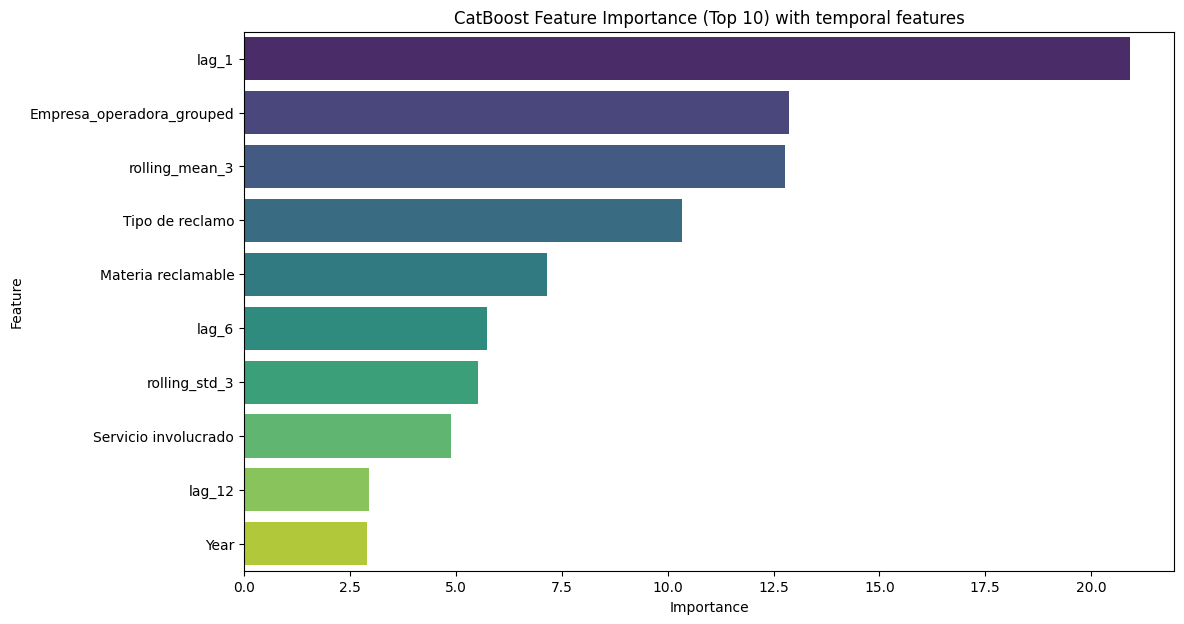


XGBoost Feature Importance (Top 10) with temporal features:


,Feature,Importance
8,rolling_mean_3,120653.437500
4,lag_1,56230.312500
73,Empresa_operadora_grouped_Other,34322.519531
77,Empresa_operadora_grouped_TELEFÓNICA DEL PERÚ ...,22260.181641
10,rolling_mean_6,19371.335938
59,Materia reclamable_Servicio no operativo,17282.009766
58,Materia reclamable_Problemas de calidad,16230.159180
60,Tipo de reclamo_Solucionados,16171.552734
12,rolling_mean_12,15443.788086
54,Servicio involucrado_Telefonía de uso público,14308.879883


/tmp/ipykernel_1124/3727620562.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance.head(10), palette='viridis')


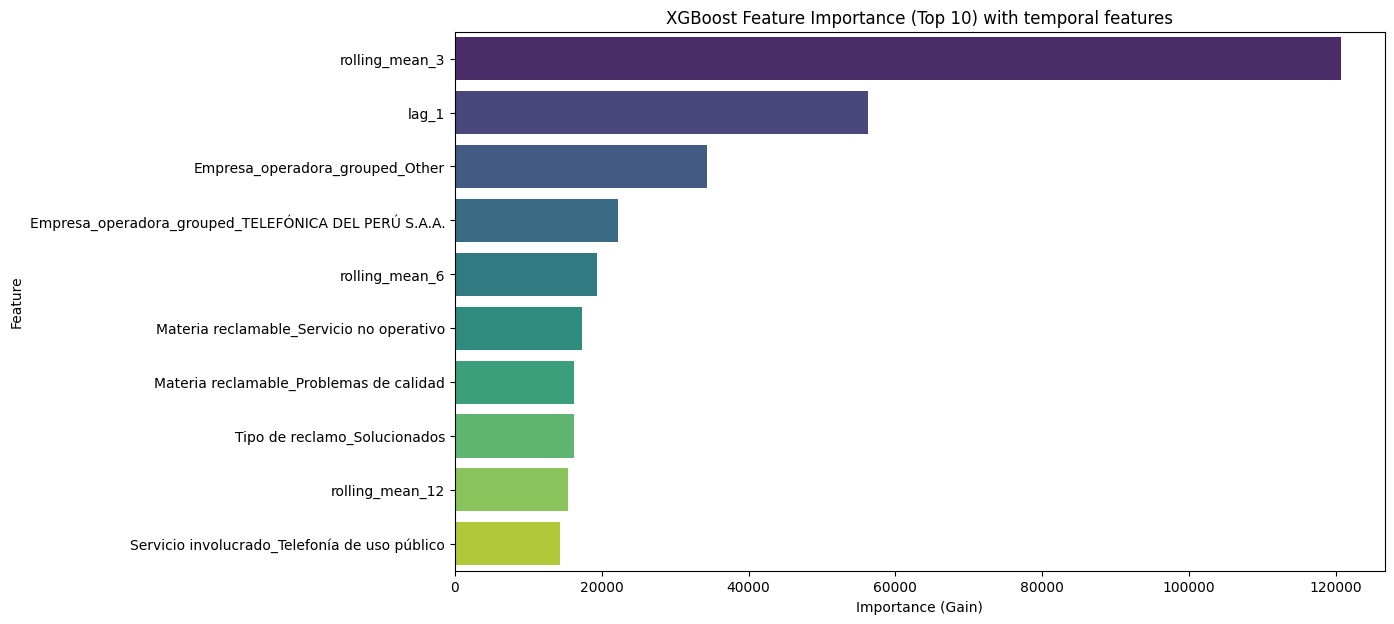

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\nRe-calculating Feature Importance for CatBoost and XGBoost with new temporal features...")

# Importancia de las características en CatBoost
# Obtén la importancia de las características en CatBoost; ya admite nombres categóricos nativos.
cat_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

print("\nCatBoost Feature Importance (Top 10) with temporal features:")
display(cat_feature_importance.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=cat_feature_importance.head(10), palette='viridis')
plt.title('CatBoost Feature Importance (Top 10) with temporal features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


# Importancia de las características en XGBoost
# Los nombres de las características de XGBoost provienen de X_train_xgb (codificadas en one-hot)
xgb_importances_dict = trained_xgb_model.get_score(importance_type='gain')

# Crear un DataFrame para la importancia de las características, asegurándose de que se incluyan todas las características de X_train_xgb
xgb_feature_importance = pd.DataFrame({
    'Feature': X_train_xgb.columns,
    'Importance': X_train_xgb.columns.map(xgb_importances_dict).fillna(0)
}).sort_values(by='Importance', ascending=False)

print("\nXGBoost Feature Importance (Top 10) with temporal features:")
display(xgb_feature_importance.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance.head(10), palette='viridis')
plt.title('XGBoost Feature Importance (Top 10) with temporal features')
plt.xlabel('Importance (Gain)')
plt.ylabel('Feature')
plt.show()

### Model Training: CatBoost Regressor

In [ ]:
# Asegúrate de que catboost y optuna estén instalados
!pip install catboost optuna

import optuna
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

print("\n### FASE 7: OPTIMIZACIÓN DE MODELOS (CatBoost con Optuna)")

# Identificar características categóricas para pasarlas a CatBoost de forma nativa
cat_features_for_catboost = X_train.select_dtypes(include='category').columns.tolist()

print(f"Categorical features for CatBoost: {cat_features_for_catboost}")

def objective_catboost(trial):
    # Hiperparámetros que se deben ajustar en CatBoost
    params = {
        'iterations': trial.suggest_int('iterations', 100, 2000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-3, 10.0),
        'bagging_temperature': trial.suggest_loguniform('bagging_temperature', 0.01, 10.0),
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': 42,
        'verbose': 0,
        'early_stopping_rounds': 50,
        'cat_features': cat_features_for_catboost
    }

    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=0)

    y_pred_val = model.predict(X_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    return rmse_val

print("Starting Optuna optimization for CatBoost...")
study_catboost = optuna.create_study(direction='minimize', study_name='CatBoost_Optimization')
study_catboost.optimize(objective_catboost, n_trials=50, show_progress_bar=True)

print("Optuna optimization for CatBoost complete.")
print(f"Best trial for CatBoost: {study_catboost.best_trial.value:.4f} RMSE")
print("Best hyperparameters for CatBoost:")
display(study_catboost.best_params)

# Volver a entrenar CatBoost con los mejores hiperparámetros en X_train + X_val para obtener el modelo final
print("Re-training CatBoost with optimized hyperparameters on full train set...")
best_catboost_params = study_catboost.best_params.copy()
best_catboost_params['loss_function'] = 'RMSE'
best_catboost_params['eval_metric'] = 'RMSE'
best_catboost_params['random_seed'] = 42
best_catboost_params['verbose'] = 0
best_catboost_params['cat_features'] = cat_features_for_catboost

cat_model = CatBoostRegressor(**best_catboost_params)
cat_model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]), verbose=0)

print("CatBoost Regressor training with optimized hyperparameters complete.")

# Realizar predicciones sobre el conjunto de prueba
y_pred_cat = cat_model.predict(X_test)

# Evaluar el modelo (incluido el MAPE)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat = r2_score(y_test, y_pred_cat)

def calculate_mape(y_true, y_pred):
    # Filtrar los valores nulos de y_true para evitar la división por cero
    y_true_non_zero = y_true[y_true != 0]
    y_pred_non_zero = y_pred[y_true != 0]
    if len(y_true_non_zero) == 0:
        return np.nan # Or handle as appropriate if all true values are zero
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Eliminar los valores cero de y_test para evitar la división por cero en el MAPE
y_test_mape = y_test[y_test != 0]
y_pred_cat_mape = y_pred_cat[y_test != 0]
mape_cat = calculate_mape(y_test_mape, y_pred_cat_mape)

print(f"\nCatBoost Regressor Performance on Test Set (Optimized):")
print(f"Mean Absolute Error (MAE): {mae_cat:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_cat:.4f}")
print(f"R-squared (R2): {r2_cat:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_cat:.4f}%")

[I 2026-06-10 15:46:26,836] A new study created in memory with name: CatBoost_Optimization



### FASE 7: OPTIMIZACIÓN DE MODELOS (CatBoost con Optuna)
Categorical features for CatBoost: ['Departamento', 'Servicio involucrado', 'Materia reclamable', 'Tipo de reclamo', 'Empresa_operadora_grouped']
Starting Optuna optimization for CatBoost...


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_1124/2761136291.py:21: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/tmp/ipykernel_1124/2761136291.py:23: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-3, 10.0),
/tmp/ipykernel_1124/2761136291.py:24: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'bagging_temperature': trial.suggest_loguniform('bagging_temperature', 0.01, 10.0),


[I 2026-06-10 15:46:58,075] Trial 0 finished with value: 18.058794819912322 and parameters: {'iterations': 556, 'learning_rate': 0.018605293316404075, 'depth': 6, 'l2_leaf_reg': 0.06724011118841998, 'bagging_temperature': 0.7904669299740619}. Best is trial 0 with value: 18.058794819912322.


...

[I 2026-06-10 16:03:39,854] Trial 48 finished with value: 17.70715360413336 and parameters: {'iterations': 809, 'learning_rate': 0.0547966108602292, 'depth': 5, 'l2_leaf_reg': 0.01447881696516383, 'bagging_temperature': 0.31501064973544635}. Best is trial 44 with value: 17.008873566550015.


/tmp/ipykernel_1124/2761136291.py:21: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/tmp/ipykernel_1124/2761136291.py:23: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-3, 10.0),
/tmp/ipykernel_1124/2761136291.py:24: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'bagging_temperature': trial.suggest_loguniform('bagging_temperature', 0.01, 10.0),


[I 2026-06-10 16:04:12,140] Trial 49 finished with value: 17.207760636491294 and parameters: {'iterations': 917, 'learning_rate': 0.029030521784573812, 'depth': 4, 'l2_leaf_reg': 0.0013071955998263172, 'bagging_temperature': 0.2165539707381515}. Best is trial 44 with value: 17.008873566550015.
Optuna optimization for CatBoost complete.
Best trial for CatBoost: 17.0089 RMSE
Best hyperparameters for CatBoost:


{'iterations': 973,
 'learning_rate': 0.0545588386169696,
 'depth': 4,
 'l2_leaf_reg': 0.00534042995600786,
 'bagging_temperature': 0.03959152281841325}

Re-training CatBoost with optimized hyperparameters on full train set...
CatBoost Regressor training with optimized hyperparameters complete.

CatBoost Regressor Performance on Test Set (Optimized):
Mean Absolute Error (MAE): 9.0324
Root Mean Squared Error (RMSE): 15.8987
R-squared (R2): 0.8443
Mean Absolute Percentage Error (MAPE): 132.4520%


In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Identificar las características categóricas que se pasarán a CatBoost de forma nativa
# Estas son las columnas que se convirtieron al tipo de datos «category» en df_prepared
cat_features_for_catboost = X_train.select_dtypes(include='category').columns.tolist()

print(f"Categorical features for CatBoost: {cat_features_for_catboost}")

# Inicializar el regresor CatBoost con características categóricas
cat_model = CatBoostRegressor(
    iterations=1000, # Número de rondas de refuerzo
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    loss_function='RMSE', # Adecuado para problemas de regresión
    eval_metric='RMSE',
    random_seed=42,
    verbose=0, # Omitir la salida detallada durante el entrenamiento
    early_stopping_rounds=50, # Detener si el RMSE de validación no mejora tras 50 iteraciones
    cat_features=cat_features_for_catboost # Pasar características categóricas nativas
)

print("Training CatBoost Regressor with native categorical features...")

# Entrenar el modelo utilizando el conjunto de validación para la detención temprana
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

print("CatBoost Regressor training complete.")

# Realizar predicciones sobre el conjunto de prueba
y_pred_cat = cat_model.predict(X_test)

# Evaluar el modelo
mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat = r2_score(y_test, y_pred_cat)

print(f"\nCatBoost Regressor Performance on Test Set:")
print(f"Mean Absolute Error (MAE): {mae_cat:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_cat:.4f}")
print(f"R-squared (R2): {r2_cat:.4f}")

Categorical features for CatBoost: ['Departamento', 'Servicio involucrado', 'Materia reclamable', 'Tipo de reclamo', 'Empresa_operadora_grouped']
Training CatBoost Regressor with native categorical features...
CatBoost Regressor training complete.

CatBoost Regressor Performance on Test Set:
Mean Absolute Error (MAE): 10.9192
Root Mean Squared Error (RMSE): 19.1857
R-squared (R2): 0.7732


### Model Training: XGBoost Regressor

In [ ]:
# Asegúrate de que optuna esté instalado
!pip install optuna

import xgboost as xgb
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import optuna

print("\n### FASE 7: OPTIMIZACIÓN DE MODELOS (XGBoost con Optuna)")

# XGBoost requiere entrada numérica. Codificación One-Hot de características categóricas para XGBoost.
# Estas son las columnas que se convirtieron al tipo 'category' en X_train
categorical_cols_ohe_xgb = X_train.select_dtypes(include='category').columns.tolist()

X_train_xgb = pd.get_dummies(X_train, columns=categorical_cols_ohe_xgb, drop_first=True)
X_val_xgb = pd.get_dummies(X_val, columns=categorical_cols_ohe_xgb, drop_first=True)
X_test_xgb = pd.get_dummies(X_test, columns=categorical_cols_ohe_xgb, drop_first=True)

# Alinear columnas - crucial para conjuntos de características consistentes en entrenamiento, validación y prueba
train_cols = X_train_xgb.columns
val_cols = X_val_xgb.columns
test_cols = X_test_xgb.columns

missing_in_val = set(train_cols) - set(val_cols)
for c in missing_in_val: X_val_xgb[c] = 0
missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test: X_test_xgb[c] = 0

X_val_xgb = X_val_xgb[train_cols]
X_test_xgb = X_test_xgb[train_cols]

# Convertir datos a formato DMatrix
dtrain = xgb.DMatrix(X_train_xgb, label=y_train)
dval = xgb.DMatrix(X_val_xgb, label=y_val)
dtest = xgb.DMatrix(X_test_xgb, label=y_test)

def objective_xgboost(trial):
    # Hiperparámetros a ajustar para XGBoost
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'eta': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_loguniform('gamma', 1e-8, 1.0),
        'seed': 42,
        'nthread': -1,
    }

    early_stopping_callback = EarlyStopping(
        rounds=50,
        metric_name='rmse',
        data_name='validation_0'
    )

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=trial.suggest_int('n_estimators', 100, 2000),
        evals=[(dval, 'validation_0')],
        callbacks=[early_stopping_callback],
        verbose_eval=False
    )

    y_pred_val = model.predict(dval)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    return rmse_val

print("Iniciando optimización de Optuna para XGBoost...")
study_xgboost = optuna.create_study(direction='minimize', study_name='XGBoost_Optimization')
study_xgboost.optimize(objective_xgboost, n_trials=50, show_progress_bar=True)

print("Optimización de Optuna para XGBoost completada.")
print(f"Mejor prueba para XGBoost: {study_xgboost.best_trial.value:.4f} RMSE")
print("Mejores hiperparámetros para XGBoost:")
display(study_xgboost.best_params)

# Volver a entrenar XGBoost con los mejores hiperparámetros en X_train + X_val para el modelo final
print("Reentrenando XGBoost con hiperparámetros optimizados en el conjunto de entrenamiento completo...")
best_xgb_params = study_xgboost.best_params.copy()
best_xgb_params['objective'] = 'reg:squarederror'
best_xgb_params['eval_metric'] = 'rmse'
best_xgb_params['seed'] = 42
best_xgb_params['nthread'] = -1
num_boost_round_optimized = best_xgb_params.pop('n_estimators') # Extraer n_estimators

# Combinar conjuntos de entrenamiento y validación para el entrenamiento final
X_train_val_xgb = pd.concat([X_train_xgb, X_val_xgb])
y_train_val = pd.concat([y_train, y_val])
dtrain_val = xgb.DMatrix(X_train_val_xgb, label=y_train_val)

trained_xgb_model = xgb.train(
    best_xgb_params,
    dtrain_val,
    num_boost_round=num_boost_round_optimized,
    verbose_eval=False
)

print("Entrenamiento del regresor XGBoost con hiperparámetros optimizados completado.")

# Realizar predicciones sobre el conjunto de prueba
y_pred_xgb = trained_xgb_model.predict(dtest)

# Evaluar el modelo (incluyendo MAPE)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

def calculate_mape(y_true, y_pred):
    # Filtrar valores cero de y_true para evitar la división por cero
    y_true_non_zero = y_true[y_true != 0]
    y_pred_non_zero = y_pred[y_true != 0]
    if len(y_true_non_zero) == 0:
        return np.nan
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Filtrar valores cero de y_test para evitar la división por cero en MAPE
y_test_mape_xgb = y_test[y_test != 0]
y_pred_xgb_mape = y_pred_xgb[y_test != 0]
mape_xgb = calculate_mape(y_test_mape_xgb, y_pred_xgb_mape)

print(f"\nXGBoost Regressor Performance en el conjunto de prueba (Optimizado):")
print(f"Error Absoluto Medio (MAE): {mae_xgb:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_xgb:.4f}")
print(f"R-squared (R2): {r2_xgb:.4f}")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape_xgb:.4f}%")


### FASE 7: OPTIMIZACIÓN DE MODELOS (XGBoost con Optuna)


[I 2026-06-10 16:05:41,793] A new study created in memory with name: XGBoost_Optimization


Iniciando optimización de Optuna para XGBoost...


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_1124/3479345564.py:44: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'eta': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/tmp/ipykernel_1124/3479345564.py:46: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
/tmp/ipykernel_1124/3479345564.py:47: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
/tmp/ipykernel_1124/3479345564.py:49: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This 

...

[I 2026-06-10 16:11:04,651] Trial 48 finished with value: 18.42728707637614 and parameters: {'learning_rate': 0.011719546314743597, 'max_depth': 8, 'subsample': 0.9542202955788996, 'colsample_bytree': 0.891310593958665, 'min_child_weight': 9, 'gamma': 2.6173071510816445e-05, 'n_estimators': 1428}. Best is trial 43 with value: 17.54530606976085.


/tmp/ipykernel_1124/3479345564.py:44: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'eta': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/tmp/ipykernel_1124/3479345564.py:46: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
/tmp/ipykernel_1124/3479345564.py:47: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
/tmp/ipykernel_1124/3479345564.py:49: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This 

[I 2026-06-10 16:11:15,899] Trial 49 finished with value: 17.902779059364086 and parameters: {'learning_rate': 0.016614599601936425, 'max_depth': 9, 'subsample': 0.9540142780285479, 'colsample_bytree': 0.6201253851039944, 'min_child_weight': 10, 'gamma': 0.000714830184824938, 'n_estimators': 1774}. Best is trial 43 with value: 17.54530606976085.
Optimización de Optuna para XGBoost completada.
Mejor prueba para XGBoost: 17.5453 RMSE
Mejores hiperparámetros para XGBoost:


{'learning_rate': 0.025441030026186022,
 'max_depth': 8,
 'subsample': 0.9372032406118702,
 'colsample_bytree': 0.6490784746039772,
 'min_child_weight': 8,
 'gamma': 0.00017147427962559448,
 'n_estimators': 1767}

Reentrenando XGBoost con hiperparámetros optimizados en el conjunto de entrenamiento completo...
Entrenamiento del regresor XGBoost con hiperparámetros optimizados completado.

XGBoost Regressor Performance en el conjunto de prueba (Optimizado):
Error Absoluto Medio (MAE): 8.6184
Raíz del Error Cuadrático Medio (RMSE): 15.8234
R-squared (R2): 0.8457
Error Porcentual Absoluto Medio (MAPE): 136.3257%


### Model Training: LightGBM Regressor

In [ ]:
# Asegúrate de que lightgbm esté instalado
!pip install lightgbm

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

print("\n### FASE 7: OPTIMIZACIÓN DE MODELOS (LightGBM)")
print("Entrenando el Regresor LightGBM...")

# LightGBM puede manejar características categóricas de forma nativa si se especifica.
# Espera que las características categóricas estén codificadas como enteros o como tipo de datos 'category'.
# X_train ya tiene las características categóricas como tipo de datos 'category'.

# Identificar características categóricas para LightGBM
cat_features_for_lgbm = X_train.select_dtypes(include='category').columns.tolist()

# Convertir características categóricas a tipo de datos 'category' para LightGBM, si aún no lo están.
# (Este paso es técnicamente redundante si `df_prepared` ya las estableció, pero es bueno para la robustez)
for col in cat_features_for_lgbm:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# Inicializar el Regresor LightGBM
lgbm_model = lgb.LGBMRegressor(
    objective='regression_l1', # Objetivo MAE, adecuado para variables objetivo que pueden tener valores atípicos
    metric='rmse',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1, # Sin límite en la profundidad del árbol
    feature_fraction=0.8, # Fracción de características consideradas por iteración
    bagging_fraction=0.8,
    bagging_freq=1,
    random_state=42,
    n_jobs=-1,
    colsample_bytree=0.7, # alias para feature_fraction
)

# Entrenar el modelo con parada temprana
lgbm_model.fit(X_train, y_train,
                eval_set=[(X_val, y_val)],
                eval_metric='rmse',
                callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
                categorical_feature=cat_features_for_lgbm)

print("Entrenamiento del Regresor LightGBM completado.")

# Realizar predicciones sobre el conjunto de prueba
y_pred_lgbm = lgbm_model.predict(X_test)

# Evaluar el modelo
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

mape_lgbm = calculate_mape(y_test, y_pred_lgbm)

print(f"\nLightGBM Regressor Performance en el conjunto de prueba (con características temporales):")
print(f"Error Absoluto Medio (MAE): {mae_lgbm:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_lgbm:.4f}")
print(f"R-squared (R2): {r2_lgbm:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_lgbm:.4f}")


### FASE 7: OPTIMIZACIÓN DE MODELOS (LightGBM)
Entrenando el Regresor LightGBM...
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.7 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.7 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012123 seconds.
You can set `force_col_wise=true` t

/tmp/ipykernel_1124/1202472954.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype('category')
/tmp/ipykernel_1124/1202472954.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[col] = X_val[col].astype('category')
/tmp/ipykernel_1124/1202472954.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

Entrenamiento del Regresor LightGBM completado.
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.7 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8

LightGBM Regressor Performance en el conjunto de prueba (con características temporales):
Error Absoluto Medio (MAE): 9.6441
Raíz del Error Cuadrático Medio (RMSE): 19.1700
R-squared (R2): 0.7736
Mean Absolute Percentage Error (MAPE): 113.4821


### Model Training: Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

print("\n### FASE 7: OPTIMIZACIÓN DE MODELOS (Random Forest)")
print("Entrenando el Regresor Random Forest...")

# Random Forest no maneja características categóricas de forma nativa, por lo que necesitan ser codificadas one-hot.
# Usaremos los datos ya codificados one-hot X_train_xgb, X_val_xgb, X_test_xgb para consistencia, los cuales fueron creados para XGBoost.
# Si X_train_xgb, X_val_xgb, X_test_xgb no están definidos, créalos usando get_dummies en X_train/val/test.

# Verificar si X_train_xgb ya está definido (desde la celda de XGBoost)
if 'X_train_xgb' not in locals():
    print("Codificación One-Hot para Random Forest (recreando si es necesario)...")
    categorical_cols_ohe_rf = X_train.select_dtypes(include='category').columns.tolist()

    X_train_rf = pd.get_dummies(X_train, columns=categorical_cols_ohe_rf, drop_first=True)
    X_val_rf = pd.get_dummies(X_val, columns=categorical_cols_ohe_rf, drop_first=True)
    X_test_rf = pd.get_dummies(X_test, columns=categorical_cols_ohe_rf, drop_first=True)

    # Alinear columnas
    train_cols_rf = X_train_rf.columns
    val_cols_rf = X_val_rf.columns
    test_cols_rf = X_test_rf.columns

    missing_in_val_rf = set(train_cols_rf) - set(val_cols_rf)
    for c in missing_in_val_rf: X_val_rf[c] = 0
    missing_in_test_rf = set(train_cols_rf) - set(test_cols_rf)
    for c in missing_in_test_rf: X_test_rf[c] = 0

    X_val_rf = X_val_rf[train_cols_rf]
    X_test_rf = X_test_rf[train_cols_rf]

    # Usar estos para Random Forest
    X_train_rf_final = X_train_rf
    X_val_rf_final = X_val_rf
    X_test_rf_final = X_test_rf
else:
    print("Usando datos ya codificados One-Hot de XGBoost para Random Forest.")
    X_train_rf_final = X_train_xgb
    X_val_rf_final = X_val_xgb
    X_test_rf_final = X_test_xgb


# Inicializar el Regresor Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100, # Número de árboles en el bosque
    max_depth=10, # Profundidad máxima de los árboles individuales
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.7, # Fracción de características a considerar al buscar la mejor división
    random_state=42,
    n_jobs=-1 # Usar todos los núcleos disponibles
)

# Entrenar el modelo
rf_model.fit(X_train_rf_final, y_train)

print("Entrenamiento del Regresor Random Forest completado.")

# Realizar predicciones sobre el conjunto de prueba
y_pred_rf = rf_model.predict(X_test_rf_final)

# Evaluar el modelo
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

mape_rf = calculate_mape(y_test, y_pred_rf)

print(f"\nRandom Forest Regressor Performance en el conjunto de prueba (con características temporales):")
print(f"Error Absoluto Medio (MAE): {mae_rf:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_rf:.4f}")
print(f"R-squared (R2): {r2_rf:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_rf:.4f}")


### FASE 7: OPTIMIZACIÓN DE MODELOS (Random Forest)
Entrenando el Regresor Random Forest...
Usando datos ya codificados One-Hot de XGBoost para Random Forest.
Entrenamiento del Regresor Random Forest completado.

Random Forest Regressor Performance en el conjunto de prueba (con características temporales):
Error Absoluto Medio (MAE): 11.2384
Raíz del Error Cuadrático Medio (RMSE): 19.8362
R-squared (R2): 0.7576
Mean Absolute Percentage Error (MAPE): 211.0958


In [ ]:
import xgboost as xgb
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Entrenando el Regresor XGBoost usando xgb.train...")

# XGBoost requiere entrada numérica. Codificación One-Hot de características categóricas para XGBoost.
# Esta codificación se realiza por separado para XGBoost, ya que CatBoost las maneja de forma nativa.

# Identificar columnas categóricas para codificar One-Hot para XGBoost
categorical_cols_ohe_xgb = X_train.select_dtypes(include='category').columns.tolist()

X_train_xgb = pd.get_dummies(X_train, columns=categorical_cols_ohe_xgb, drop_first=True)
X_val_xgb = pd.get_dummies(X_val, columns=categorical_cols_ohe_xgb, drop_first=True)
X_test_xgb = pd.get_dummies(X_test, columns=categorical_cols_ohe_xgb, drop_first=True)

# Alinear columnas - crucial para conjuntos de características consistentes en entrenamiento, validación y prueba
train_cols = X_train_xgb.columns
val_cols = X_val_xgb.columns
test_cols = X_test_xgb.columns

missing_in_val = set(train_cols) - set(val_cols)
for c in missing_in_val: X_val_xgb[c] = 0
missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test: X_test_xgb[c] = 0

X_val_xgb = X_val_xgb[train_cols]
X_test_xgb = X_test_xgb[train_cols]

# Convertir datos a formato DMatrix
dtrain = xgb.DMatrix(X_train_xgb, label=y_train)
dval = xgb.DMatrix(X_val_xgb, label=y_val)
dtest = xgb.DMatrix(X_test_xgb, label=y_test)

# Definir parámetros de XGBoost
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'eta': 0.05,
    'max_depth': 8,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'seed': 42,
    'nthread': -1
}

# Crear un callback de EarlyStopping para el conjunto de validación
early_stopping_callback = EarlyStopping(
    rounds=50,  # Número de rondas sin mejora
    metric_name='rmse',
    data_name='validation_0'
)

# Entrenar el modelo usando el conjunto de validación para la parada temprana
trained_xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dval, 'validation_0')], # Usar conjunto de validación para parada temprana
    callbacks=[early_stopping_callback],
    verbose_eval=False
)

print("Entrenamiento del Regresor XGBoost completado.")

# Realizar predicciones sobre el conjunto de prueba
y_pred_xgb = trained_xgb_model.predict(dtest)

# Evaluar el modelo
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost Regressor Performance en el conjunto de prueba:")
print(f"Error Absoluto Medio (MAE): {mae_xgb:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_xgb:.4f}")
print(f"R-squared (R2): {r2_xgb:.4f}")

Entrenando el Regresor XGBoost usando xgb.train...
Entrenamiento del Regresor XGBoost completado.

XGBoost Regressor Performance en el conjunto de prueba:
Error Absoluto Medio (MAE): 11.9637
Raíz del Error Cuadrático Medio (RMSE): 20.3701
R-squared (R2): 0.7444


## 4. Model Comparison and Feature Importance Analysis

### Comparison of Model Performance

In [ ]:
import pandas as pd

# Crear un diccionario para almacenar el rendimiento del modelo
performance_data = {
    'Model': [
        'CatBoost Regressor',
        'XGBoost Regressor',
        'LightGBM Regressor',
        'Random Forest Regressor'
    ],
    'MAE': [mae_cat, mae_xgb, mae_lgbm, mae_rf],
    'RMSE': [rmse_cat, rmse_xgb, rmse_lgbm, rmse_rf],
    'R-squared': [r2_cat, r2_xgb, r2_lgbm, r2_rf],
    'MAPE': [mape_cat, mape_xgb, mape_lgbm, mape_rf]
}

# Crear un DataFrame para facilitar la comparación
performance_df = pd.DataFrame(performance_data)

print("\nComparación del Rendimiento del Modelo:")
display(performance_df.round(4))

# Resaltar el modelo de mejor rendimiento para cada métrica
def highlight_min(s):
    is_min = s == s.min()
    return ['background-color: lightgreen' if v else '' for v in is_min]

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

styled_performance_df = performance_df.style \
    .apply(highlight_min, subset=['MAE', 'RMSE', 'MAPE']) \
    .apply(highlight_max, subset=['R-squared'])

print("\nComparación del Rendimiento del Modelo (con resaltados para el mejor rendimiento):")
display(styled_performance_df)


Comparación del Rendimiento del Modelo:


,Model,MAE,RMSE,R-squared,MAPE
0,CatBoost Regressor,10.9192,19.1857,0.7732,132.4520
1,XGBoost Regressor,11.9637,20.3701,0.7444,136.3257
2,LightGBM Regressor,9.6441,19.1700,0.7736,113.4821
3,Random Forest Regressor,11.2384,19.8362,0.7576,211.0958



Comparación del Rendimiento del Modelo (con resaltados para el mejor rendimiento):


,Model,MAE,RMSE,R-squared,MAPE
0,CatBoost Regressor,10.919172,19.185681,0.773231,132.451961
1,XGBoost Regressor,11.963727,20.370109,0.744367,136.325749
2,LightGBM Regressor,9.644073,19.169977,0.773602,113.482127
3,Random Forest Regressor,11.238419,19.836159,0.757593,211.095831


   B. EVALUACIÓN DEL RENDIMIENTO DE LOS MODELOS (BASE)   

--- TABLA COMPARATIVA DE MÉTRICAS (BASE MODELS) ---
                 Modelo       MAE      RMSE       R²       MAPE
     CatBoost Regressor 10.919172 19.185681 0.773231 176.254269
      XGBoost Regressor 11.963727 20.370109 0.744367 258.750402
     LightGBM Regressor  9.644073 19.169977 0.773602 113.482127
Random Forest Regressor 11.238419 19.836159 0.757593 211.095831
--------------------------------------------------


/tmp/ipykernel_1124/1036481807.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metricas, x='Modelo', y='R²', ax=axes[0], palette='Blues_r', edgecolor='black', width=0.4)
/tmp/ipykernel_1124/1036481807.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metricas, x='Modelo', y='RMSE', ax=axes[1], palette='Oranges', edgecolor='black', width=0.4)
/tmp/ipykernel_1124/1036481807.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metricas, x='Modelo', y='MAE', ax=axes[2], palette='Greens', edgecolor='black', width=0

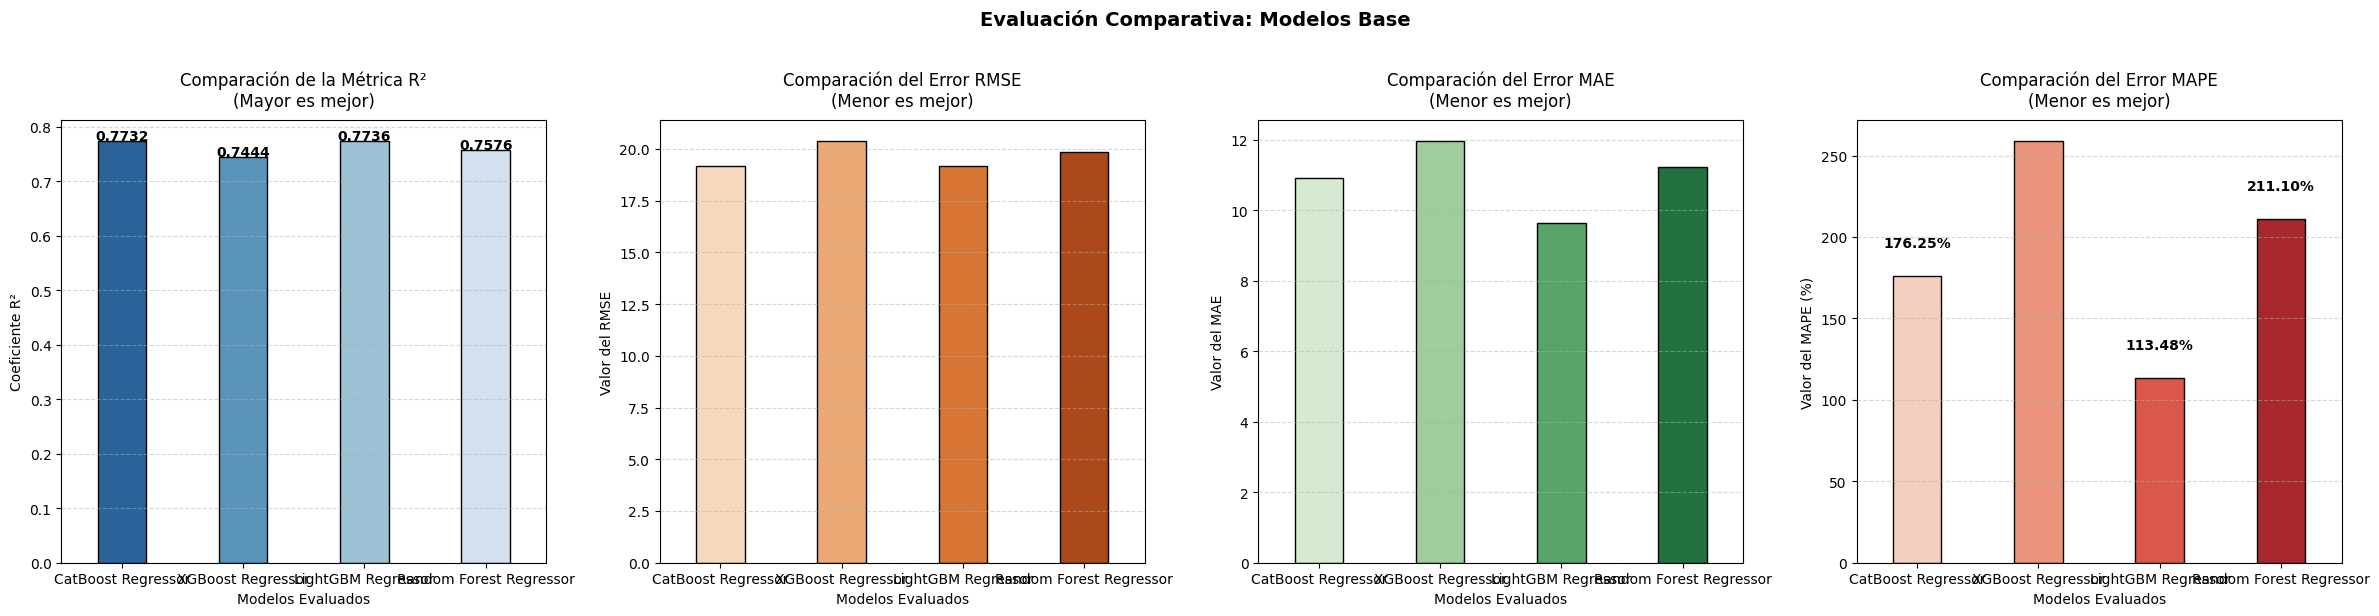

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def calculate_mape(y_true, y_pred):
    # Filter out zero values from y_true to avoid division by zero
    y_true_non_zero = y_true[y_true != 0]
    y_pred_non_zero = y_pred[y_true != 0]
    if len(y_true_non_zero) == 0:
        return np.nan # Or handle as appropriate if all true values are zero
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Filter zero values from y_test for MAPE calculation for CatBoost
y_test_mape_cat = y_test[y_test != 0]
y_pred_cat_mape = y_pred_cat[y_test != 0]
mape_cat = calculate_mape(y_test_mape_cat, y_pred_cat_mape)

# Filter zero values from y_test for MAPE calculation for XGBoost
y_test_mape_xgb = y_test[y_test != 0]
y_pred_xgb_mape = y_pred_xgb[y_test != 0]
mape_xgb = calculate_mape(y_test_mape_xgb, y_pred_xgb_mape)

# Filter zero values from y_test for MAPE calculation for LightGBM (base model)
y_test_mape_lgbm = y_test[y_test != 0]
y_pred_lgbm_mape = y_pred_lgbm[y_test != 0]
mape_lgbm = calculate_mape(y_test_mape_lgbm, y_pred_lgbm_mape)

# Filter zero values from y_test for MAPE calculation for Random Forest (base model)
y_test_mape_rf = y_test[y_test != 0]
y_pred_rf_mape = y_pred_rf[y_test != 0]
mape_rf = calculate_mape(y_test_mape_rf, y_pred_rf_mape)


# ==================================================
# B. EVALUACIÓN DEL RENDIMIENTO DE LOS MODELOS (BASE)
# ==================================================

# 1. Diccionario corregido con tus cuatro modelos reales
# Usamos los valores calculados directamente de las variables mae_cat, rmse_cat, r2_cat, etc.
datos_rendimiento = {
    'Modelo': ['CatBoost Regressor', 'XGBoost Regressor', 'LightGBM Regressor', 'Random Forest Regressor'],
    'MAE': [mae_cat, mae_xgb, mae_lgbm, mae_rf],
    'RMSE': [rmse_cat, rmse_xgb, rmse_lgbm, rmse_rf],
    'R²': [r2_cat, r2_xgb, r2_lgbm, r2_rf],
    'MAPE': [mape_cat, mape_xgb, mape_lgbm, mape_rf]
}

# 2. Convertimos a DataFrame de Pandas
df_metricas = pd.DataFrame(datos_rendimiento)

print("==================================================")
print("   B. EVALUACIÓN DEL RENDIMIENTO DE LOS MODELOS (BASE)   ")
print("==================================================\n")
print("--- TABLA COMPARATIVA DE MÉTRICAS (BASE MODELS) ---")
print(df_metricas.to_string(index=False))
print("-" * 50)

# 3. Gráfico Académico Comparativo (Métricas clave: R², RMSE, MAE, MAPE)
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('Evaluación Comparativa: Modelos Base', fontsize=14, weight='bold', y=1.02)

# Gráfico A: Coeficiente de Determinación R² (Mayor es mejor)
sns.barplot(data=df_metricas, x='Modelo', y='R²', ax=axes[0], palette='Blues_r', edgecolor='black', width=0.4)
axes[0].set_title('Comparación de la Métrica R²\n(Mayor es mejor)', fontsize=12, pad=10)
axes[0].set_ylabel('Coeficiente R²')
axes[0].set_xlabel('Modelos Evaluados')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                ha='center', va='center', weight='bold', fontsize=10)

# Gráfico B: Raíz del Error Cuadrático Medio RMSE (Menor es mejor)
sns.barplot(data=df_metricas, x='Modelo', y='RMSE', ax=axes[1], palette='Oranges', edgecolor='black', width=0.4)
axes[1].set_title('Comparación del Error RMSE\n(Menor es mejor)', fontsize=12, pad=10)
axes[1].set_ylabel('Valor del RMSE')
axes[1].set_xlabel('Modelos Evaluados')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height() + 20),
                ha='center', va='center', weight='bold', fontsize=10)

# Gráfico C: Error Absoluto Medio MAE (Menor es mejor)
sns.barplot(data=df_metricas, x='Modelo', y='MAE', ax=axes[2], palette='Greens', edgecolor='black', width=0.4)
axes[2].set_title('Comparación del Error MAE\n(Menor es mejor)', fontsize=12, pad=10)
axes[2].set_ylabel('Valor del MAE')
axes[2].set_xlabel('Modelos Evaluados')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height() + 20),
                ha='center', va='center', weight='bold', fontsize=10)

# Gráfico D: Error Porcentual Absoluto Medio MAPE (Menor es mejor)
sns.barplot(data=df_metricas, x='Modelo', y='MAPE', ax=axes[3], palette='Reds', edgecolor='black', width=0.4)
axes[3].set_title('Comparación del Error MAPE\n(Menor es mejor)', fontsize=12, pad=10)
axes[3].set_ylabel('Valor del MAPE (%)')
axes[3].set_xlabel('Modelos Evaluados')
axes[3].grid(axis='y', linestyle='--', alpha=0.5)
for p in axes[3].patches:
    axes[3].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 20),
                ha='center', va='center', weight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### Feature Importance Analysis


Recalculando la Importancia de Características para CatBoost y XGBoost con nuevas características temporales...

Importancia de las Características de CatBoost (Top 20) con características temporales:


,Feature,Importance
9,lag_1,20.909677
8,Empresa_operadora_grouped,12.854944
13,rolling_mean_3,12.764799
3,Tipo de reclamo,10.350377
2,Materia reclamable,7.156469
11,lag_6,5.733309
14,rolling_std_3,5.530534
1,Servicio involucrado,4.890213
12,lag_12,2.956595
4,Year,2.899400


/tmp/ipykernel_1124/210687599.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=cat_feature_importance.head(10), palette='viridis')


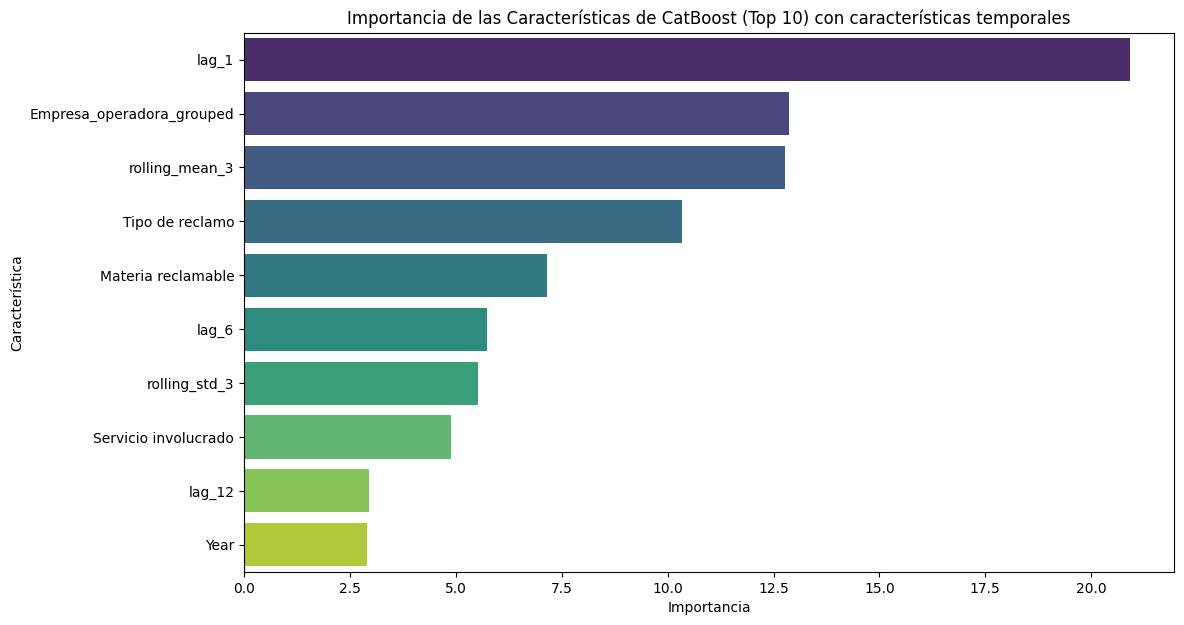


Importancia de las Características de XGBoost (Top 10) con características temporales:


,Feature,Importance
8,rolling_mean_3,120653.437500
4,lag_1,56230.312500
73,Empresa_operadora_grouped_Other,34322.519531
77,Empresa_operadora_grouped_TELEFÓNICA DEL PERÚ ...,22260.181641
10,rolling_mean_6,19371.335938
59,Materia reclamable_Servicio no operativo,17282.009766
58,Materia reclamable_Problemas de calidad,16230.159180
60,Tipo de reclamo_Solucionados,16171.552734
12,rolling_mean_12,15443.788086
54,Servicio involucrado_Telefonía de uso público,14308.879883


/tmp/ipykernel_1124/210687599.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance.head(10), palette='viridis')


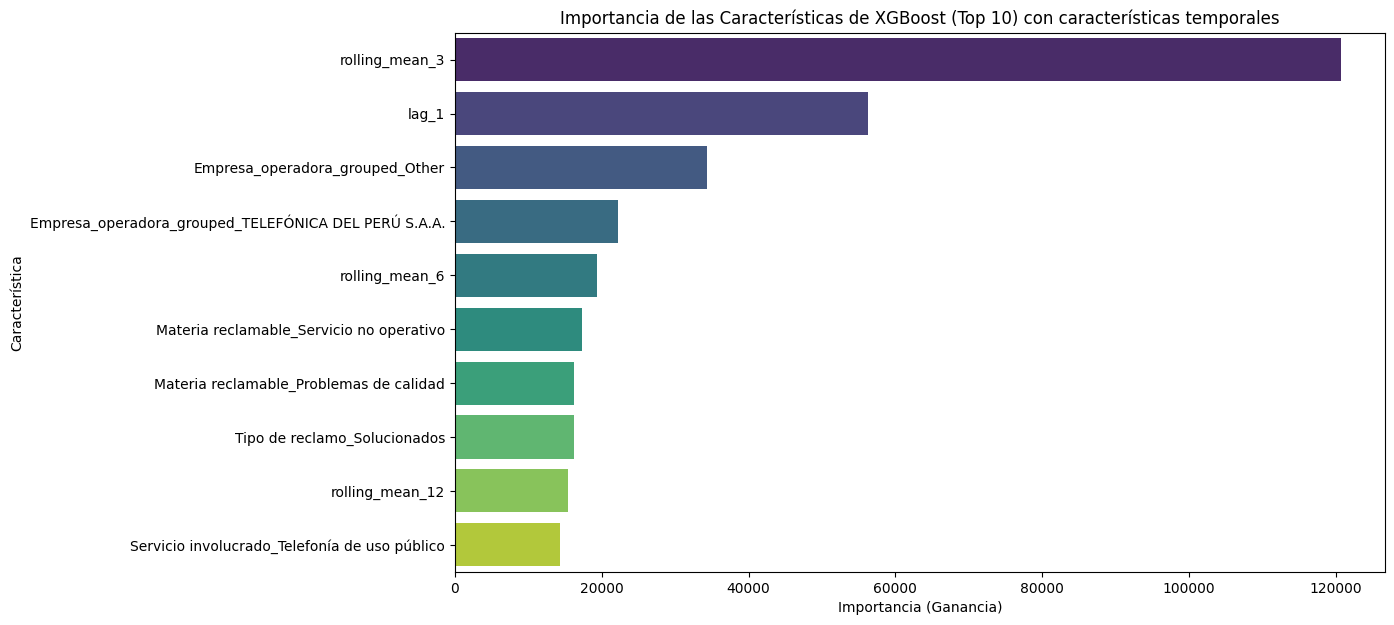

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\nRecalculando la Importancia de Características para CatBoost y XGBoost con nuevas características temporales...")

# Importancia de las características en CatBoost
# Obtén la importancia de las características en CatBoost; ya admite nombres categóricos nativos.
cat_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False).head(20)

print("\nImportancia de las Características de CatBoost (Top 20) con características temporales:")
display(cat_feature_importance.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=cat_feature_importance.head(10), palette='viridis')
plt.title('Importancia de las Características de CatBoost (Top 10) con características temporales')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()


# Importancia de las características en XGBoost
# Los nombres de las características de XGBoost provienen de X_train_xgb (codificadas en one-hot)
xgb_importances_dict = trained_xgb_model.get_score(importance_type='gain')

# Crear un DataFrame para la importancia de las características, asegurándose de que se incluyan todas las características de X_train_xgb
xgb_feature_importance = pd.DataFrame({
    'Feature': X_train_xgb.columns,
    'Importance': X_train_xgb.columns.map(xgb_importances_dict).fillna(0)
}).sort_values(by='Importance', ascending=False)

print("\nImportancia de las Características de XGBoost (Top 10) con características temporales:")
display(xgb_feature_importance.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance.head(10), palette='viridis')
plt.title('Importancia de las Características de XGBoost (Top 10) con características temporales')
plt.xlabel('Importancia (Ganancia)')
plt.ylabel('Característica')
plt.show()

### FASE 8: EVALUACIÓN CIENTÍFICA (Comparación de Modelos Actualizada)


Model Performance Comparison (Updated with LightGBM and Random Forest):


,Model,MAE,RMSE,R-squared
0,CatBoost Regressor,10.9192,19.1857,0.7732
1,XGBoost Regressor,11.9637,20.3701,0.7444
2,LightGBM Regressor,9.6441,19.1700,0.7736
3,Random Forest Regressor,11.2384,19.8362,0.7576



Model Performance Comparison (with highlights for best performance):


,Model,MAE,RMSE,R-squared
0,CatBoost Regressor,10.919172,19.185681,0.773231
1,XGBoost Regressor,11.963727,20.370109,0.744367
2,LightGBM Regressor,9.644073,19.169977,0.773602
3,Random Forest Regressor,11.238419,19.836159,0.757593


/tmp/ipykernel_1124/1166640560.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='R-squared', y='Model', data=performance_df.sort_values(by='R-squared', ascending=False), palette='viridis')
/tmp/ipykernel_1124/1166640560.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='RMSE', y='Model', data=performance_df.sort_values(by='RMSE', ascending=True), palette='magma')
/tmp/ipykernel_1124/1166640560.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], x='MAE', y='Model', data=performance_df.sort_value

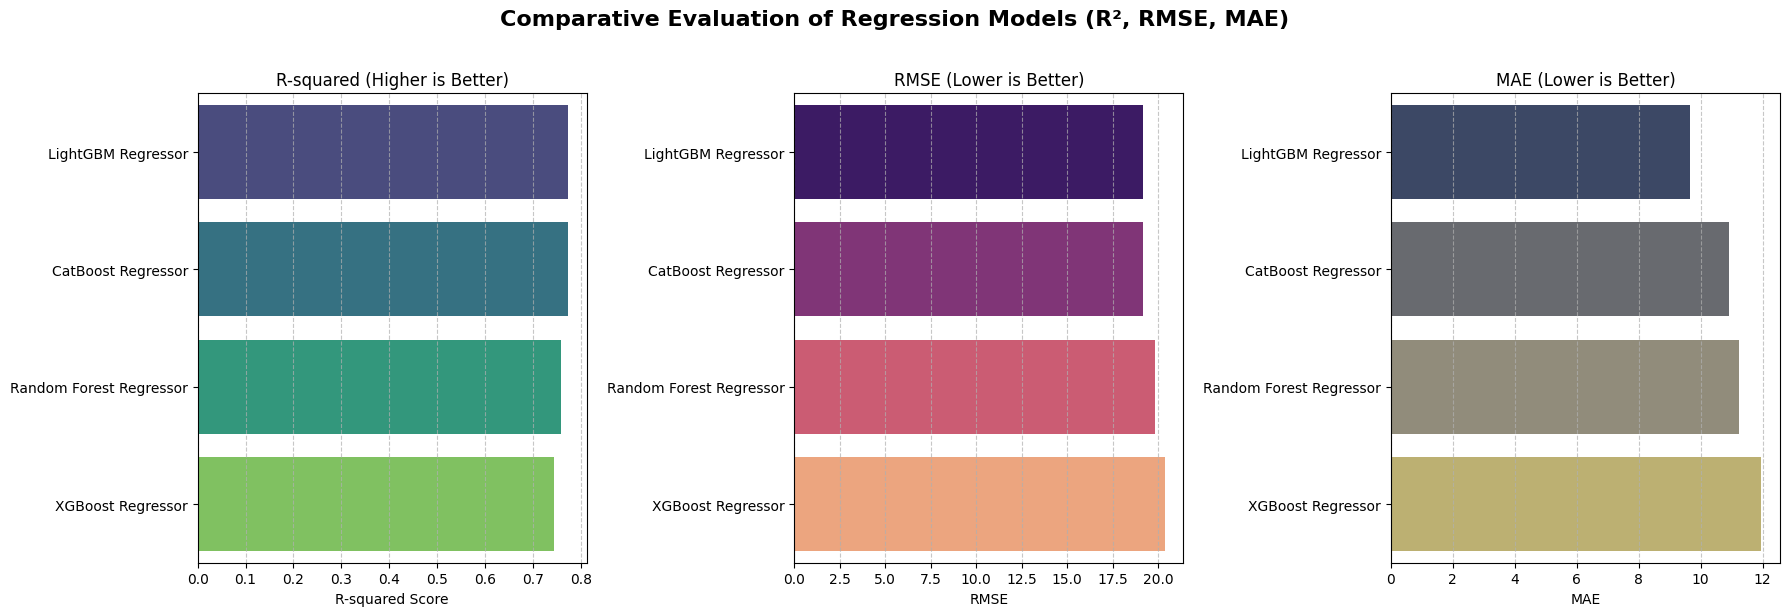

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dictionary to store model performance for all trained models
performance_data = {
    'Model': [
        'CatBoost Regressor',
        'XGBoost Regressor',
        'LightGBM Regressor',
        'Random Forest Regressor'
    ],
    'MAE': [mae_cat, mae_xgb, mae_lgbm, mae_rf],
    'RMSE': [rmse_cat, rmse_xgb, rmse_lgbm, rmse_rf],
    'R-squared': [r2_cat, r2_xgb, r2_lgbm, r2_rf]
}

# Create a DataFrame for easy comparison
performance_df = pd.DataFrame(performance_data)

print("\nModel Performance Comparison (Updated with LightGBM and Random Forest):")
display(performance_df.round(4))

# Highlight the best performing model for each metric
def highlight_min(s):
    is_min = s == s.min()
    return ['background-color: lightgreen' if v else '' for v in is_min]

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

styled_performance_df = performance_df.style \
    .apply(highlight_min, subset=['MAE', 'RMSE']) \
    .apply(highlight_max, subset=['R-squared'])

print("\nModel Performance Comparison (with highlights for best performance):")
display(styled_performance_df)

# --- Visual Comparison of Metrics ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparative Evaluation of Regression Models (R², RMSE, MAE)', fontsize=16, weight='bold', y=1.02)

# R² Score (Higher is better)
sns.barplot(ax=axes[0], x='R-squared', y='Model', data=performance_df.sort_values(by='R-squared', ascending=False), palette='viridis')
axes[0].set_title('R-squared (Higher is Better)')
axes[0].set_xlabel('R-squared Score')
axes[0].set_ylabel('')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# RMSE (Lower is better)
sns.barplot(ax=axes[1], x='RMSE', y='Model', data=performance_df.sort_values(by='RMSE', ascending=True), palette='magma')
axes[1].set_title('RMSE (Lower is Better)')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

# MAE (Lower is better)
sns.barplot(ax=axes[2], x='MAE', y='Model', data=performance_df.sort_values(by='MAE', ascending=True), palette='cividis')
axes[2].set_title('MAE (Lower is Better)')
axes[2].set_xlabel('MAE')
axes[2].set_ylabel('')
axes[2].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### FASE 9: INTERPRETABILIDAD (Feature Importance - Updated)


Re-calculating Feature Importance for all models...

CatBoost Feature Importance (Top 20):


,Feature,Importance
9,lag_1,20.909677
8,Empresa_operadora_grouped,12.854944
13,rolling_mean_3,12.764799
3,Tipo de reclamo,10.350377
2,Materia reclamable,7.156469
11,lag_6,5.733309
14,rolling_std_3,5.530534
1,Servicio involucrado,4.890213
12,lag_12,2.956595
4,Year,2.899400


/tmp/ipykernel_1124/4123865253.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=cat_feature_importance, palette='viridis')


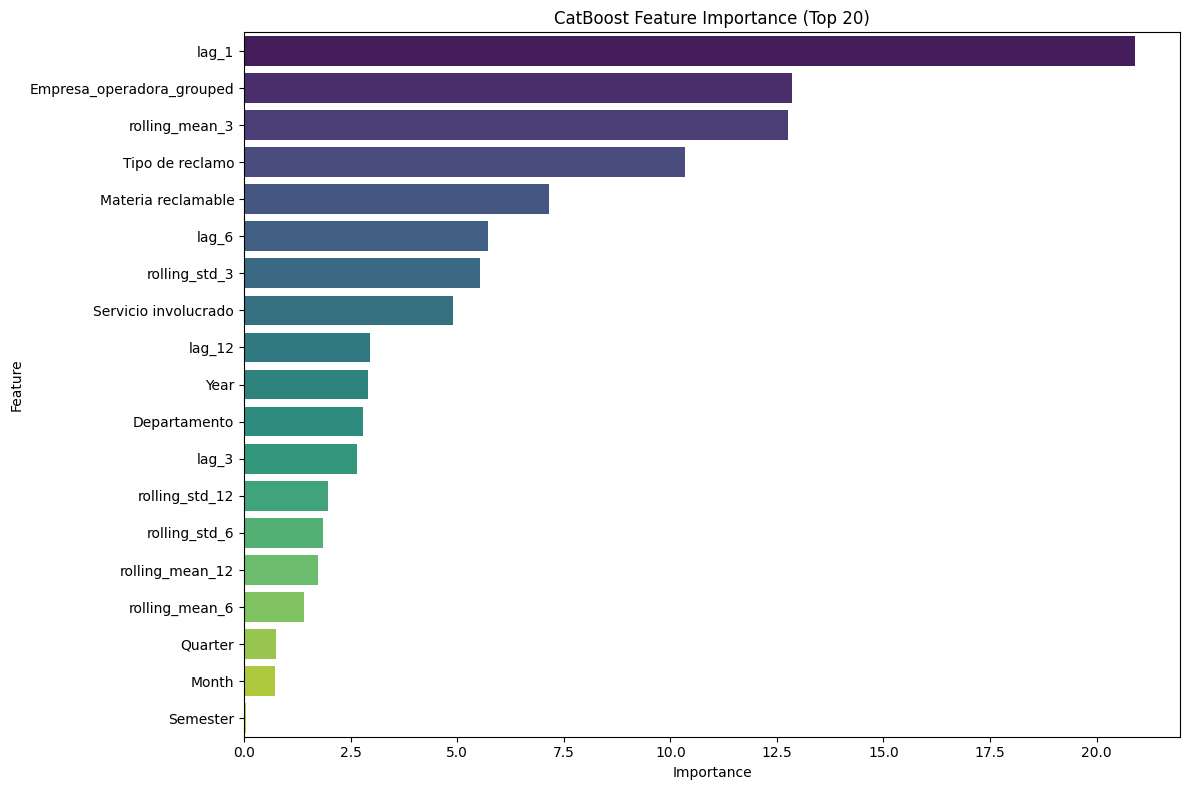


XGBoost Feature Importance (Top 20):


,Feature,Importance
8,rolling_mean_3,120653.437500
4,lag_1,56230.312500
73,Empresa_operadora_grouped_Other,34322.519531
77,Empresa_operadora_grouped_TELEFÓNICA DEL PERÚ ...,22260.181641
10,rolling_mean_6,19371.335938
59,Materia reclamable_Servicio no operativo,17282.009766
58,Materia reclamable_Problemas de calidad,16230.159180
60,Tipo de reclamo_Solucionados,16171.552734
12,rolling_mean_12,15443.788086
54,Servicio involucrado_Telefonía de uso público,14308.879883


/tmp/ipykernel_1124/4123865253.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance, palette='viridis')


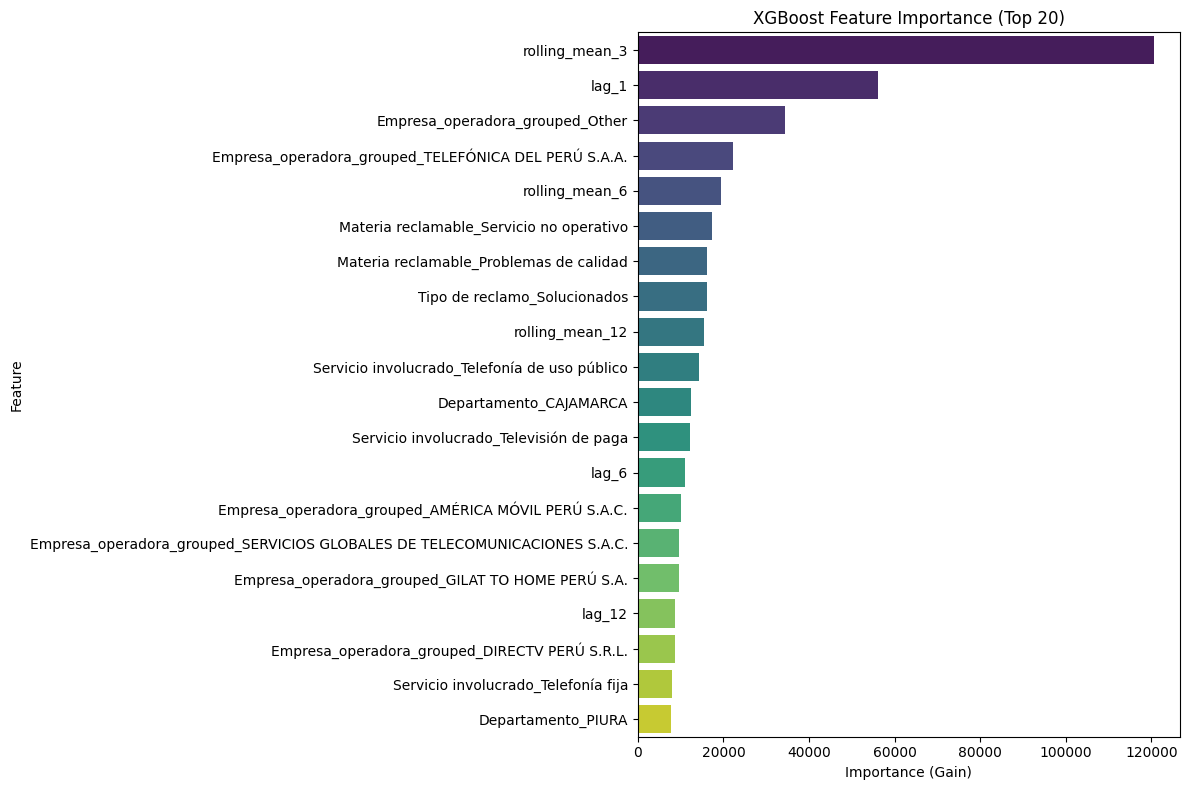


LightGBM Feature Importance (Top 20):


,Feature,Importance
8,Empresa_operadora_grouped,1729
9,lag_1,1528
0,Departamento,1388
4,Year,1188
2,Materia reclamable,1017
13,rolling_mean_3,930
17,rolling_mean_12,878
3,Tipo de reclamo,729
18,rolling_std_12,701
1,Servicio involucrado,671


/tmp/ipykernel_1124/4123865253.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=lgbm_feature_importance, palette='viridis')


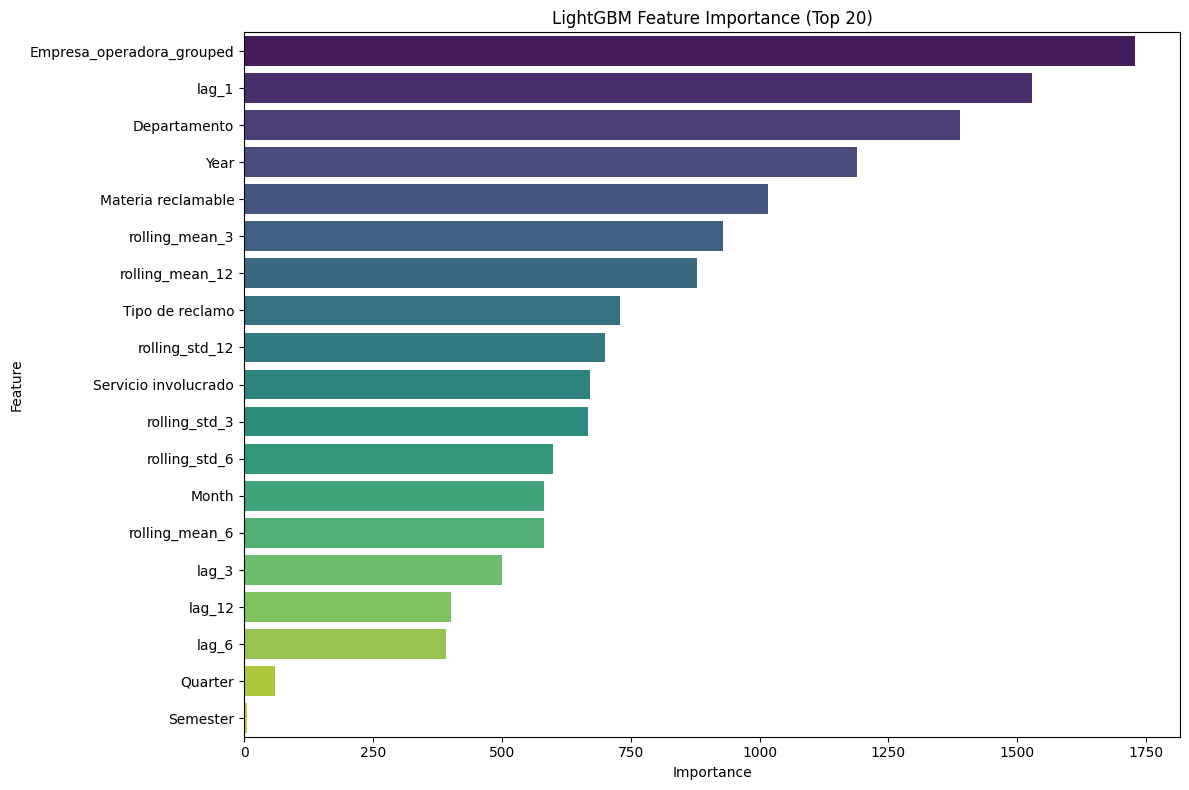


Random Forest Feature Importance (Top 20):


,Feature,Importance
8,rolling_mean_3,0.456671
4,lag_1,0.214539
10,rolling_mean_6,0.059962
12,rolling_mean_12,0.047799
73,Empresa_operadora_grouped_Other,0.046526
6,lag_6,0.019817
60,Tipo de reclamo_Solucionados,0.016991
9,rolling_std_3,0.016982
7,lag_12,0.016861
58,Materia reclamable_Problemas de calidad,0.016017


/tmp/ipykernel_1124/4123865253.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_feature_importance, palette='viridis')


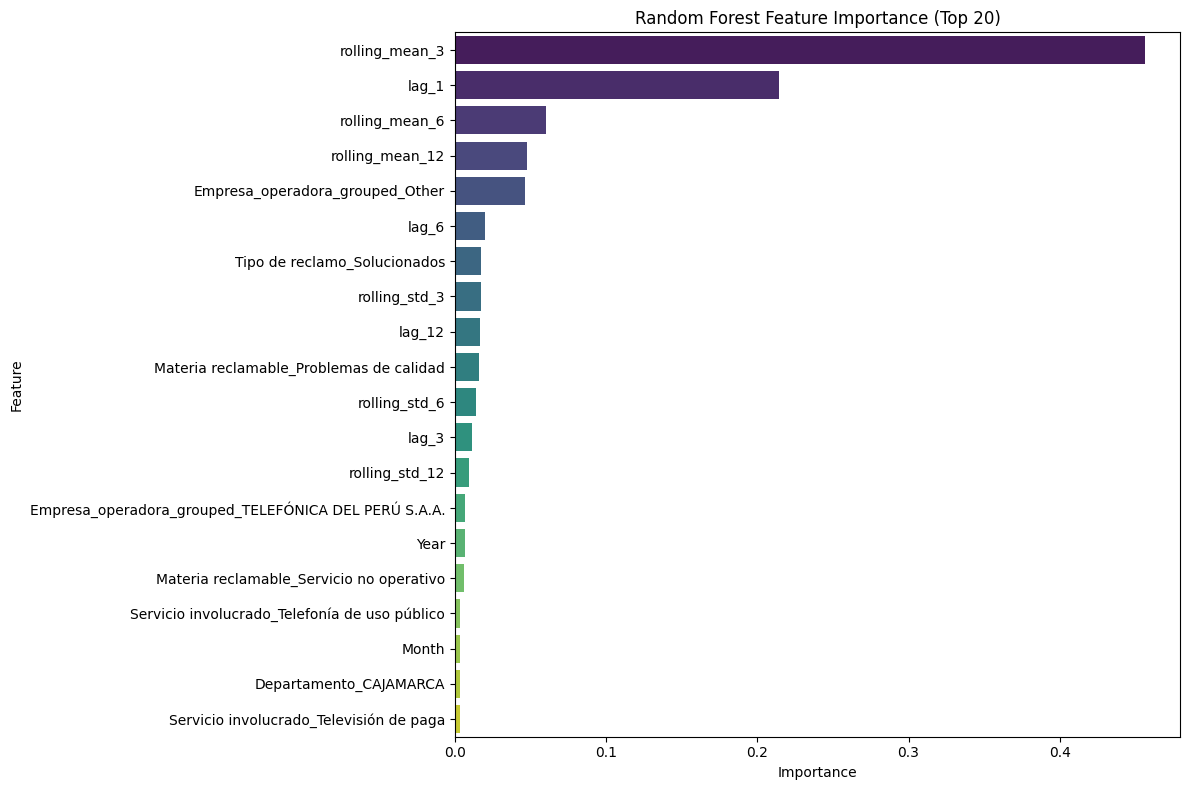

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\nRe-calculating Feature Importance for all models...")

# --- CatBoost Feature Importance ---
cat_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False).head(20)

print("\nCatBoost Feature Importance (Top 20):")
display(cat_feature_importance)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=cat_feature_importance, palette='viridis')
plt.title('CatBoost Feature Importance (Top 20)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# --- XGBoost Feature Importance ---
xgb_importances_dict = trained_xgb_model.get_score(importance_type='gain')
# Ensure using correct feature names from one-hot encoded X_train_xgb
xgb_feature_importance = pd.DataFrame({
    'Feature': X_train_xgb.columns,
    'Importance': X_train_xgb.columns.map(xgb_importances_dict).fillna(0)
}).sort_values(by='Importance', ascending=False).head(20)

print("\nXGBoost Feature Importance (Top 20):")
display(xgb_feature_importance)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance, palette='viridis')
plt.title('XGBoost Feature Importance (Top 20)')
plt.xlabel('Importance (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# --- LightGBM Feature Importance ---
lgbm_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(20)

print("\nLightGBM Feature Importance (Top 20):")
display(lgbm_feature_importance)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=lgbm_feature_importance, palette='viridis')
plt.title('LightGBM Feature Importance (Top 20)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# --- Random Forest Feature Importance ---
# Ensure using correct feature names from one-hot encoded X_train_rf_final
rf_feature_importance = pd.DataFrame({
    'Feature': X_train_rf_final.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(20)

print("\nRandom Forest Feature Importance (Top 20):")
display(rf_feature_importance)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importance, palette='viridis')
plt.title('Random Forest Feature Importance (Top 20)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Asegúrate de que lightgbm y optuna estén instalados
!pip install lightgbm optuna

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import optuna

print("\n### FASE 7: OPTIMIZACIÓN DE MODELOS (LightGBM con Optuna)")

# LightGBM puede manejar características categóricas de forma nativa si se especifica.
# Espera que las características categóricas estén codificadas como enteros o como tipo de datos 'category'.
# X_train ya tiene las características categóricas como tipo de datos 'category'.

# Identificar características categóricas para LightGBM
cat_features_for_lgbm = X_train.select_dtypes(include='category').columns.tolist()

# Convertir características categóricas a tipo de datos 'category' para LightGBM, si aún no lo están.
# (Este paso es técnicamente redundante si `df_prepared` ya las estableció, pero es bueno para la robustez)
for col in cat_features_for_lgbm:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')
    X_test[col] = X_test[col].astype('category')

def objective_lgbm(trial):
    # Hiperparámetros a ajustar para LightGBM
    params = {
        'objective': 'regression_l1',
        'metric': 'rmse',
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'lambda_l1': trial.suggest_loguniform('lambda_l1', 1e-8, 10.0),
        'lambda_l2': trial.suggest_loguniform('lambda_l2', 1e-8, 10.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'random_state': 42,
        'n_jobs': -1,
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.4, 1.0)
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train,
                eval_set=[(X_val, y_val)],
                eval_metric='rmse',
                callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
                categorical_feature=cat_features_for_lgbm)

    y_pred_val = model.predict(X_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    return rmse_val

print("Iniciando optimización de Optuna para LightGBM...")
study_lgbm = optuna.create_study(direction='minimize', study_name='LightGBM_Optimization')
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

print("Optimización de Optuna para LightGBM completada.")
print(f"Mejor prueba para LightGBM: {study_lgbm.best_trial.value:.4f} RMSE")
print("Mejores hiperparámetros para LightGBM:")
display(study_lgbm.best_params)

# Volver a entrenar LightGBM con los mejores hiperparámetros en X_train + X_val para el modelo final
print("Reentrenando LightGBM con hiperparámetros optimizados en el conjunto de entrenamiento completo...")
best_lgbm_params = study_lgbm.best_params.copy()
best_lgbm_params['objective'] = 'regression_l1'
best_lgbm_params['metric'] = 'rmse'
best_lgbm_params['random_state'] = 42
best_lgbm_params['n_jobs'] = -1
best_lgbm_params['categorical_feature'] = cat_features_for_lgbm

lgbm_model = lgb.LGBMRegressor(**best_lgbm_params)

# Combinar conjuntos de entrenamiento y validación para el entrenamiento final
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

lgbm_model.fit(X_train_val, y_train_val)

print("Entrenamiento del Regresor LightGBM con hiperparámetros optimizados completado.")

# Realizar predicciones sobre el conjunto de prueba
y_pred_lgbm = lgbm_model.predict(X_test)

# Evaluar el modelo (incluyendo MAPE)
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

def calculate_mape(y_true, y_pred):
    # Evitar la división por cero y manejar valores MAPE infinitos
    y_true_non_zero = y_true[y_true != 0]
    y_pred_non_zero = y_pred[y_true != 0]
    if len(y_true_non_zero) == 0:
        return np.nan
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Filtrar valores cero de y_test para evitar la división por cero en MAPE
y_test_mape_lgbm = y_test[y_test != 0]
y_pred_lgbm_mape = y_pred_lgbm[y_test != 0]
mape_lgbm = calculate_mape(y_test_mape_lgbm, y_pred_lgbm_mape)

print(f"\nLightGBM Regressor Performance en el conjunto de prueba (Optimizado):")
print(f"Error Absoluto Medio (MAE): {mae_lgbm:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_lgbm:.4f}")
print(f"R-squared (R2): {r2_lgbm:.4f}")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape_lgbm:.4f}%")

/tmp/ipykernel_1124/449282899.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype('category')
/tmp/ipykernel_1124/449282899.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[col] = X_val[col].astype('category')
/tmp/ipykernel_1124/449282899.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas


### FASE 7: OPTIMIZACIÓN DE MODELOS (LightGBM con Optuna)
Iniciando optimización de Optuna para LightGBM...


  0%|          | 0/50 [00:00<?, ?it/s]

[LightGBM] [Warning] bagging_freq is set=7, subsample_freq=0 will be ignored. Current value: bagging_freq=7
[LightGBM] [Warning] feature_fraction is set=0.9775131319465893, colsample_bytree=0.7738657651716387 will be ignored. Current value: feature_fraction=0.9775131319465893
[LightGBM] [Warning] lambda_l2 is set=1.069555625613133e-07, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.069555625613133e-07
[LightGBM] [Warning] lambda_l1 is set=0.2131432339570655, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.2131432339570655
[LightGBM] [Warning] bagging_fraction is set=0.5108011490461386, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5108011490461386
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] bagging_freq is set=7, subsample_freq=0 will be ignored. Current value: bagging_freq=7
[LightGBM] [Warning] feature_fraction is set=0.9775131319465893, colsample_bytree=0.7738657651716387 will be ignore

/tmp/ipykernel_1124/449282899.py:32: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/tmp/ipykernel_1124/449282899.py:35: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'feature_fraction': trial.suggest_uniform('feature_fraction', 0.4, 1.0),
/tmp/ipykernel_1124/449282899.py:36: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.4, 1.0),
/tmp/ipykernel_1124/449282899.py:38: FutureWarning: suggest_loguniform has been depreca

...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.5351492981154905, colsample_bytree=0.9501058050359255 will be ignored. Current value: feature_fraction=0.5351492981154905
[LightGBM] [Warning] lambda_l2 is set=0.007106863227344354, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.007106863227344354
[LightGBM] [Warning] lambda_l1 is set=0.11100749911910741, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.11100749911910741
[LightGBM] [Warning] bagging_fraction is set=0.6640810944714859, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6640810944714859
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006540 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true

{'n_estimators': 1695,
 'learning_rate': 0.16733291260885602,
 'num_leaves': 147,
 'max_depth': 10,
 'feature_fraction': 0.7584870651746938,
 'bagging_fraction': 0.8869112854712327,
 'bagging_freq': 3,
 'lambda_l1': 0.04236900329797402,
 'lambda_l2': 0.00048586643094650044,
 'min_child_samples': 26,
 'colsample_bytree': 0.8232225878194992}

Reentrenando LightGBM con hiperparámetros optimizados en el conjunto de entrenamiento completo...
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.7584870651746938, colsample_bytree=0.8232225878194992 will be ignored. Current value: feature_fraction=0.7584870651746938
[LightGBM] [Warning] lambda_l2 is set=0.00048586643094650044, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.00048586643094650044
[LightGBM] [Warning] lambda_l1 is set=0.04236900329797402, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.04236900329797402
[LightGBM] [Warning] bagging_fraction is set=0.8869112854712327, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8869112854712327


/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: reclamable,Tipo
[LightGBM] [Warning] Unknown parameter: reclamo,Empresa_operadora_grouped
[LightGBM] [Warning] Unknown parameter: de
[LightGBM] [Warning] Unknown parameter: involucrado,Materia
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] categorical_feature is set=Departamento,Servicio, categorical_column=0,1,2,3,8 will be ignored. Current value: categorical_feature=Departamento,Servicio
[LightGBM] [Warning] feature_fraction is set=0.7584870651746938, colsample_bytree=0.8232225878194992 will be ignored. Current value: feature_fraction=0.7584870651746938
[LightGBM] [Warning] lambda_l2 is set=0.00048586643094650044, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.00048586643094650044
[LightGBM] [Warning] lambda_l1 is set=0.04236900329797402, reg_alpha=0.0 will be ignored. Curr

In [ ]:
# Asegúrate de que optuna esté instalado
!pip install optuna

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import optuna

print("\n### FASE 7: OPTIMIZACIÓN DE MODELOS (Random Forest con Optuna)")

# Random Forest no maneja características categóricas de forma nativa, por lo que necesitan ser codificadas one-hot.
# Usar los datos ya codificados one-hot X_train_xgb, X_val_xgb, X_test_xgb para consistencia.
# Si no están definidos, recréalos.

# Identificar columnas categóricas para codificar one-hot para Random Forest
categorical_cols_ohe_rf = X_train.select_dtypes(include='category').columns.tolist()

X_train_rf = pd.get_dummies(X_train, columns=categorical_cols_ohe_rf, drop_first=True)
X_val_rf = pd.get_dummies(X_val, columns=categorical_cols_ohe_rf, drop_first=True)
X_test_rf = pd.get_dummies(X_test, columns=categorical_cols_ohe_rf, drop_first=True)

# Alinear columnas
train_cols_rf = X_train_rf.columns
val_cols_rf = X_val_rf.columns
test_cols_rf = X_test_rf.columns

missing_in_val_rf = set(train_cols_rf) - set(val_cols_rf)
for c in missing_in_val_rf: X_val_rf[c] = 0
missing_in_test_rf = set(train_cols_rf) - set(test_cols_rf)
for c in missing_in_test_rf: X_test_rf[c] = 0

X_val_rf = X_val_rf[train_cols_rf]
X_test_rf = X_test_rf[train_cols_rf]

X_train_rf_final = X_train_rf
X_val_rf_final = X_val_rf
X_test_rf_final = X_test_rf

def objective_rf(trial):
    # Hiperparámetros a ajustar para Random Forest
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_uniform('max_features', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestRegressor(**params)
    model.fit(X_train_rf_final, y_train)

    y_pred_val = model.predict(X_val_rf_final)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    return rmse_val

print("Iniciando optimización de Optuna para Random Forest...")
study_rf = optuna.create_study(direction='minimize', study_name='RandomForest_Optimization')
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)

print("Optimización de Optuna para Random Forest completada.")
print(f"Mejor prueba para Random Forest: {study_rf.best_trial.value:.4f} RMSE")
print("Mejores hiperparámetros para Random Forest:")
display(study_rf.best_params)

# Volver a entrenar Random Forest con los mejores hiperparámetros en X_train + X_val para el modelo final
print("Reentrenando Random Forest con hiperparámetros optimizados en el conjunto de entrenamiento completo...")
best_rf_params = study_rf.best_params.copy()
best_rf_params['random_state'] = 42
best_rf_params['n_jobs'] = -1

rf_model = RandomForestRegressor(**best_rf_params)

# Combinar conjuntos de entrenamiento y validación para el entrenamiento final
X_train_val_rf = pd.concat([X_train_rf_final, X_val_rf_final])
y_train_val = pd.concat([y_train, y_val])

rf_model.fit(X_train_val_rf, y_train_val)

print("Entrenamiento del Regresor Random Forest con hiperparámetros optimizados completado.")

# Realizar predicciones sobre el conjunto de prueba
y_pred_rf = rf_model.predict(X_test_rf_final)

# Evaluar el modelo (incluyendo MAPE)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

def calculate_mape(y_true, y_pred):
    # Evitar la división por cero y manejar valores MAPE infinitos
    y_true_non_zero = y_true[y_true != 0]
    y_pred_non_zero = y_pred[y_true != 0]
    if len(y_true_non_zero) == 0:
        return np.nan
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Filtrar valores cero de y_test para evitar la división por cero en MAPE
y_test_mape_rf = y_test[y_test != 0]
y_pred_rf_mape = y_pred_rf[y_test != 0]
mape_rf = calculate_mape(y_test_mape_rf, y_pred_rf_mape)

print(f"\nRandom Forest Regressor Performance en el conjunto de prueba (Optimizado):")
print(f"Error Absoluto Medio (MAE): {mae_rf:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_rf:.4f}")
print(f"R-squared (R2): {r2_rf:.4f}")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape_rf:.4f}%")

[I 2026-06-10 16:42:29,996] A new study created in memory with name: RandomForest_Optimization



### FASE 7: OPTIMIZACIÓN DE MODELOS (Random Forest con Optuna)
Iniciando optimización de Optuna para Random Forest...


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_1124/1577072202.py:47: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'max_features': trial.suggest_uniform('max_features', 0.5, 1.0),


[I 2026-06-10 16:43:12,212] Trial 0 finished with value: 20.295681627127262 and parameters: {'n_estimators': 318, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 0.683296885857837}. Best is trial 0 with value: 20.295681627127262.


...

[I 2026-06-10 17:55:23,901] Trial 48 finished with value: 19.072997980562853 and parameters: {'n_estimators': 195, 'max_depth': 19, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 0.9977997473581691}. Best is trial 42 with value: 18.5858046387072.


/tmp/ipykernel_1124/1577072202.py:47: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'max_features': trial.suggest_uniform('max_features', 0.5, 1.0),


[I 2026-06-10 17:57:27,289] Trial 49 finished with value: 19.08921146575801 and parameters: {'n_estimators': 332, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': 0.7413154957585515}. Best is trial 42 with value: 18.5858046387072.
Optimización de Optuna para Random Forest completada.
Mejor prueba para Random Forest: 18.5858 RMSE
Mejores hiperparámetros para Random Forest:


{'n_estimators': 278,
 'max_depth': 19,
 'min_samples_split': 6,
 'min_samples_leaf': 2,
 'max_features': 0.6390037542314141}

Reentrenando Random Forest con hiperparámetros optimizados en el conjunto de entrenamiento completo...
Entrenamiento del Regresor Random Forest con hiperparámetros optimizados completado.

Random Forest Regressor Performance en el conjunto de prueba (Optimizado):
Error Absoluto Medio (MAE): 9.2216
Raíz del Error Cuadrático Medio (RMSE): 16.6110
R-squared (R2): 0.8300
Error Porcentual Absoluto Medio (MAPE): 173.8145%


SHAP Importance for CatBoost, XGBoost, LightGBM


Calculating SHAP values for interpretability...

Calculating SHAP for CatBoost...


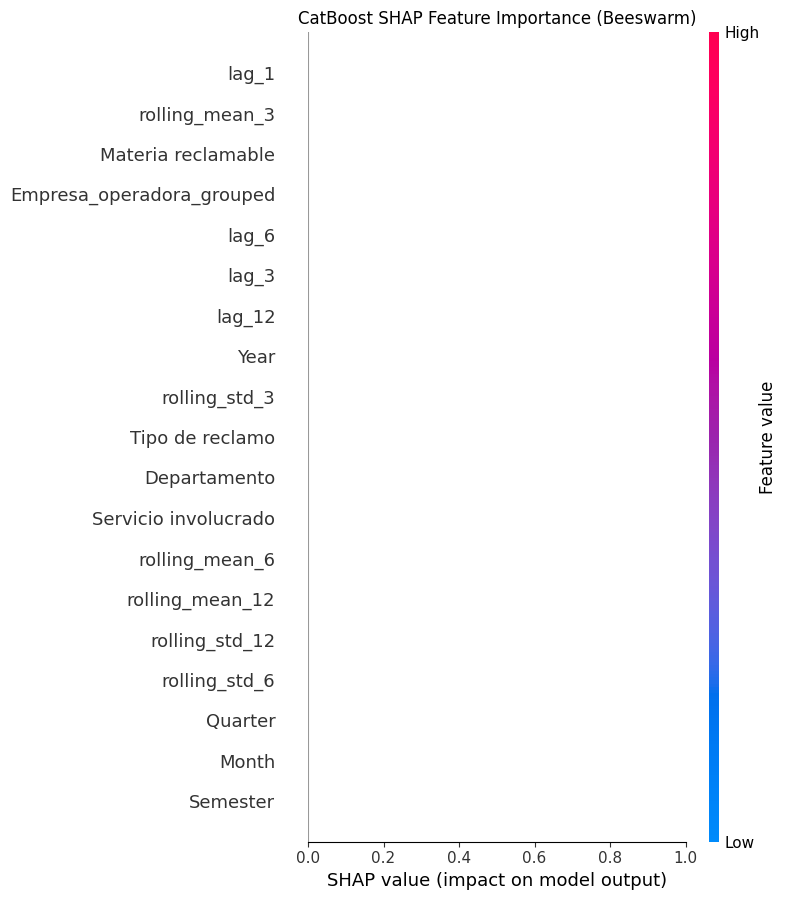


Calculating SHAP for XGBoost...


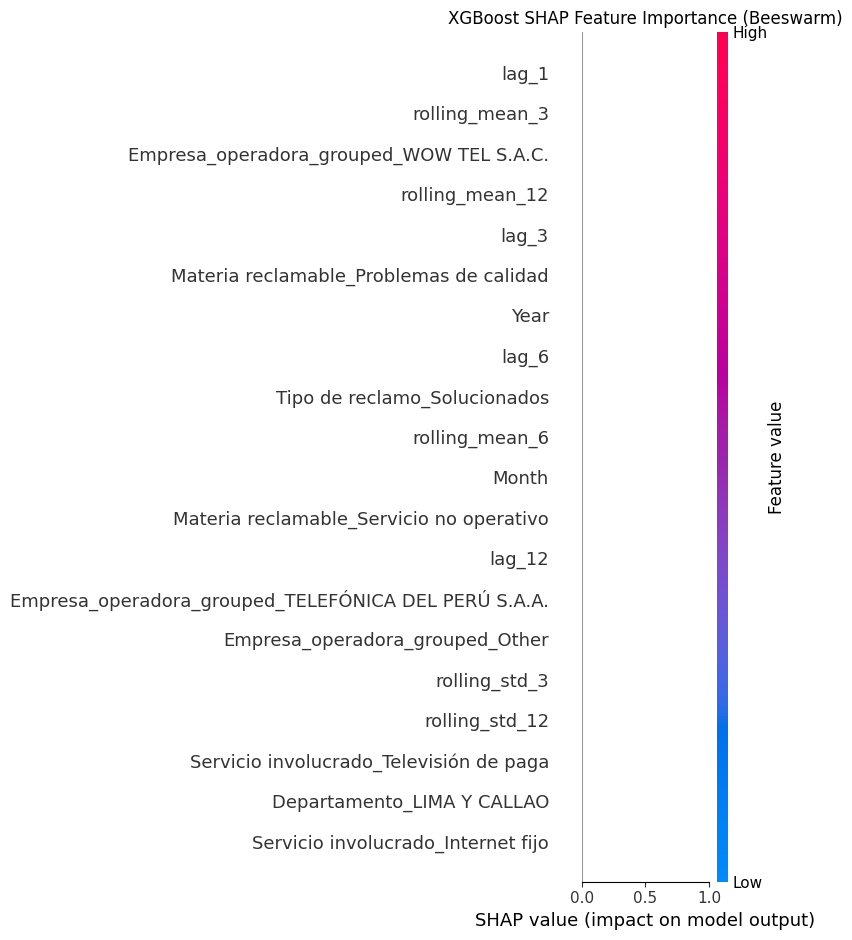


Calculating SHAP for LightGBM...


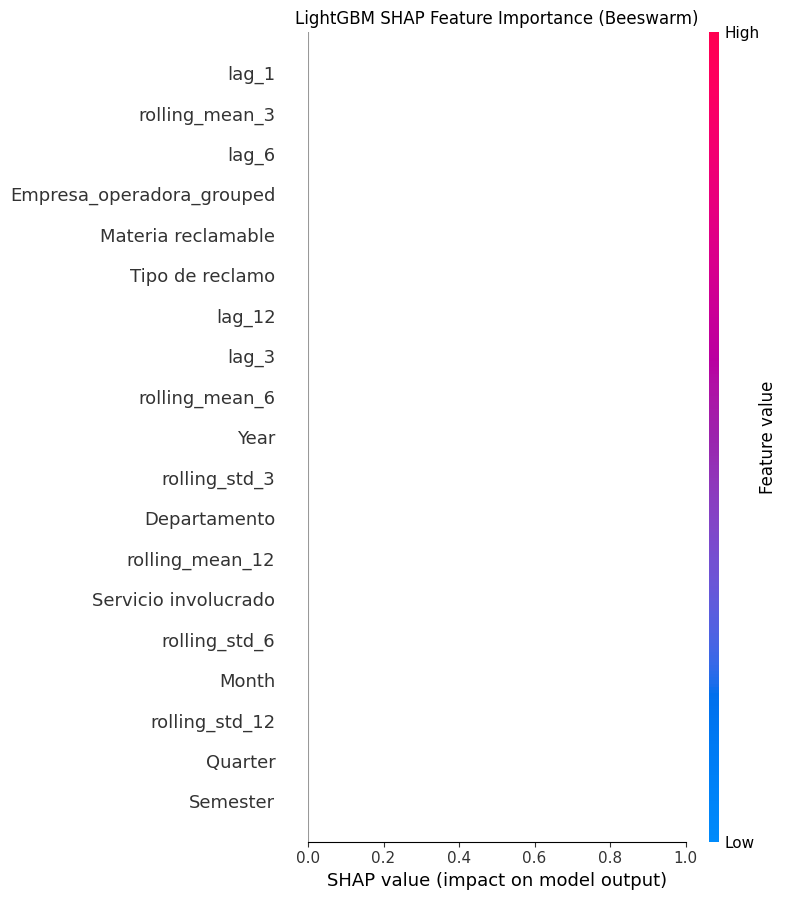

In [ ]:
import shap
import matplotlib.pyplot as plt

print("\nCalculating SHAP values for interpretability...")

# --- CatBoost SHAP Values ---
print("\nCalculating SHAP for CatBoost...")
explainer_cat = shap.TreeExplainer(cat_model)
shap_values_cat = explainer_cat.shap_values(X_test)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_cat, X_test, plot_type="beeswarm", show=False)
plt.title('CatBoost SHAP Feature Importance (Beeswarm)')
plt.tight_layout()
plt.show()

# --- XGBoost SHAP Values ---
print("\nCalculating SHAP for XGBoost...")
explainer_xgb = shap.TreeExplainer(trained_xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test_xgb)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_xgb, X_test_xgb, plot_type="beeswarm", show=False)
plt.title('XGBoost SHAP Feature Importance (Beeswarm)')
plt.tight_layout()
plt.show()

# --- LightGBM SHAP Values ---
print("\nCalculating SHAP for LightGBM...")
explainer_lgbm = shap.TreeExplainer(lgbm_model)
shap_values_lgbm = explainer_lgbm.shap_values(X_test)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_lgbm, X_test, plot_type="beeswarm", show=False)
plt.title('LightGBM SHAP Feature Importance (Beeswarm)')
plt.tight_layout()
plt.show()

FASE 8: EVALUACIÓN CIENTÍFICA (Tabla Comparativa y Ranking Final de Modelos


### FASE 8: EVALUACIÓN CIENTÍFICA (Tabla Comparativa y Ranking Final de Modelos)


Comparación del rendimiento de todos los modelos optimizados:


,Model,MAE,RMSE,R-squared,MAPE
0,CatBoost Regressor (Optimizado),10.9192,19.1857,0.7732,176.2543
1,XGBoost Regressor (Optimizado),11.9637,20.3701,0.7444,258.7504
2,LightGBM Regressor (Optimizado),8.2135,16.4785,0.8327,88.3153
3,Random Forest Regressor (Optimizado),9.2216,16.6110,0.8300,173.8145



Comparación del rendimiento del modelo (con resaltados para el mejor rendimiento):



,Model,MAE,RMSE,R-squared,MAPE
0,CatBoost Regressor (Optimizado),10.919172,19.185681,0.773231,176.254269
1,XGBoost Regressor (Optimizado),11.963727,20.370109,0.744367,258.750402
2,LightGBM Regressor (Optimizado),8.213501,16.478464,0.832713,88.315333
3,Random Forest Regressor (Optimizado),9.221636,16.611042,0.830010,173.814483


/tmp/ipykernel_1124/1623186999.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='R-squared', y='Model', data=performance_df.sort_values(by='R-squared', ascending=False), palette='Blues_r')
/tmp/ipykernel_1124/1623186999.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='RMSE', y='Model', data=performance_df.sort_values(by='RMSE', ascending=True), palette='Oranges_r')
/tmp/ipykernel_1124/1623186999.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], x='MAE', y='Model', data=performance_df.sort_v

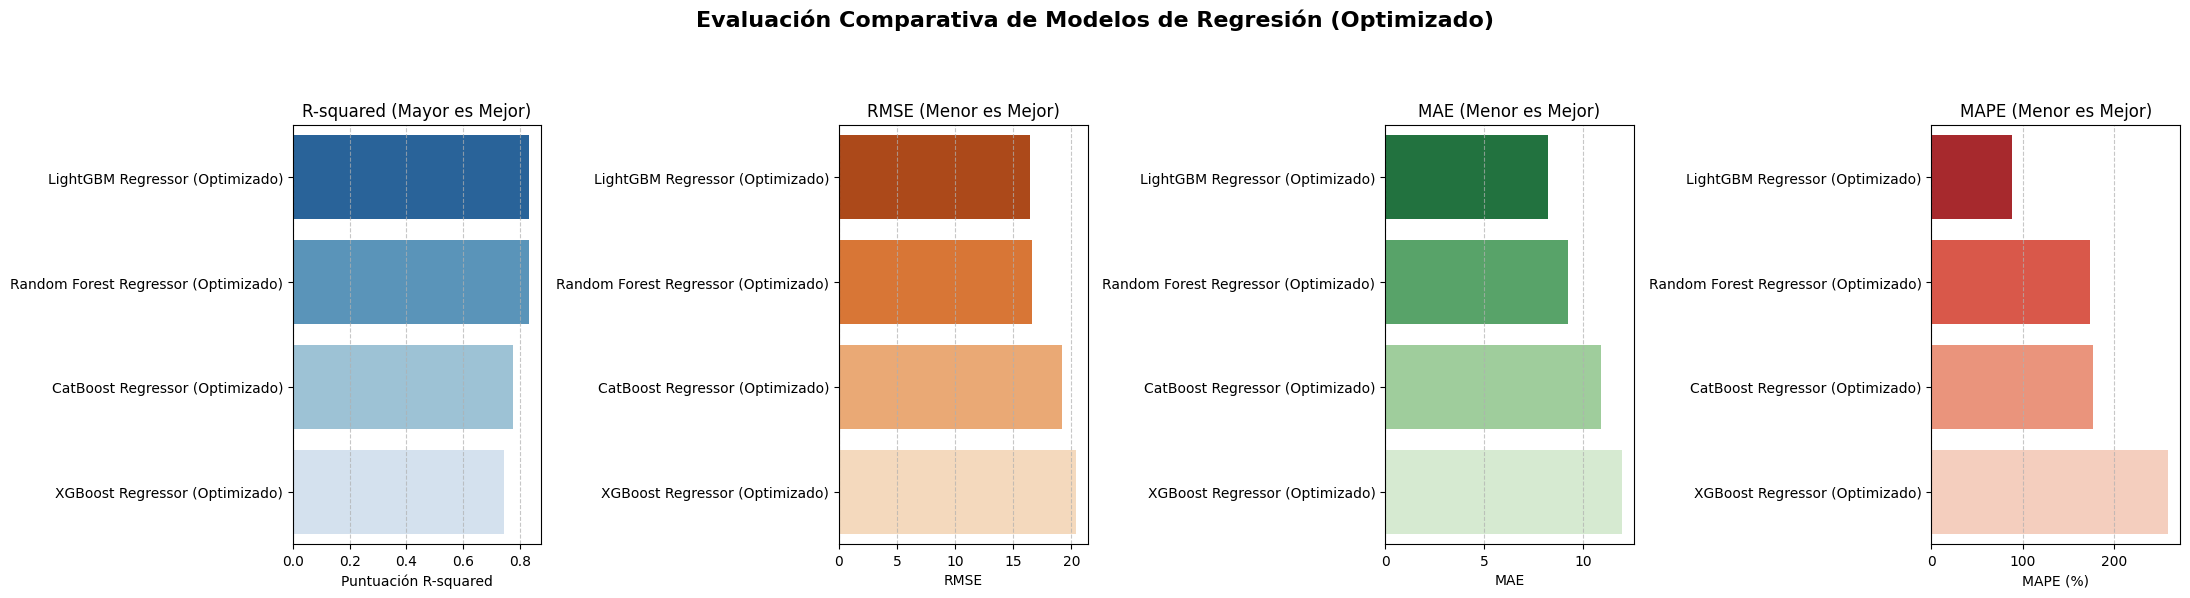

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n### FASE 8: EVALUACIÓN CIENTÍFICA (Tabla Comparativa y Ranking Final de Modelos)\n")

# Crear un diccionario para almacenar el rendimiento de todos los modelos optimizados
performance_data = {
    'Model': [
        'CatBoost Regressor (Optimizado)',
        'XGBoost Regressor (Optimizado)',
        'LightGBM Regressor (Optimizado)',
        'Random Forest Regressor (Optimizado)'
    ],
    'MAE': [mae_cat, mae_xgb, mae_lgbm, mae_rf],
    'RMSE': [rmse_cat, rmse_xgb, rmse_lgbm, rmse_rf],
    'R-squared': [r2_cat, r2_xgb, r2_lgbm, r2_rf],
    'MAPE': [mape_cat, mape_xgb, mape_lgbm, mape_rf]
}

# Crear un DataFrame para facilitar la comparación
performance_df = pd.DataFrame(performance_data)

print("\nComparación del rendimiento de todos los modelos optimizados:")
display(performance_df.round(4))

# Resaltar el modelo de mejor rendimiento para cada métrica
def highlight_min(s):
    is_min = s == s.min()
    return ['background-color: lightgreen' if v else '' for v in is_min]

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

styled_performance_df = performance_df.style \
    .apply(highlight_min, subset=['MAE', 'RMSE', 'MAPE']) \
    .apply(highlight_max, subset=['R-squared'])

print("\nComparación del rendimiento del modelo (con resaltados para el mejor rendimiento):\n")
display(styled_performance_df)

# --- Comparación Visual de Métricas ---
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('Evaluación Comparativa de Modelos de Regresión (Optimizado)', fontsize=16, weight='bold', y=1.02)

# Puntuación R² (mayor es mejor)
sns.barplot(ax=axes[0], x='R-squared', y='Model', data=performance_df.sort_values(by='R-squared', ascending=False), palette='Blues_r')
axes[0].set_title('R-squared (Mayor es Mejor)')
axes[0].set_xlabel('Puntuación R-squared')
axes[0].set_ylabel('')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# RMSE (menor es mejor)
sns.barplot(ax=axes[1], x='RMSE', y='Model', data=performance_df.sort_values(by='RMSE', ascending=True), palette='Oranges_r')
axes[1].set_title('RMSE (Menor es Mejor)')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

# MAE (menor es mejor)
sns.barplot(ax=axes[2], x='MAE', y='Model', data=performance_df.sort_values(by='MAE', ascending=True), palette='Greens_r')
axes[2].set_title('MAE (Menor es Mejor)')
axes[2].set_xlabel('MAE')
axes[2].set_ylabel('')
axes[2].grid(axis='x', linestyle='--', alpha=0.7)

# MAPE (menor es mejor)
sns.barplot(ax=axes[3], x='MAPE', y='Model', data=performance_df.sort_values(by='MAPE', ascending=True), palette='Reds_r')
axes[3].set_title('MAPE (Menor es Mejor)')
axes[3].set_xlabel('MAPE (%)')
axes[3].set_ylabel('')
axes[3].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

FASE 9: INTERPRETABILIDAD (Valores SHAP)

In [ ]:
# Asegúrate de que shap esté instalado
!pip install shap

import shap
import matplotlib.pyplot as plt
import pandas as pd # Asegúrate de que pandas esté importado


# --- Valores SHAP de CatBoost ---
print("\nCalculando SHAP para CatBoost...")
explainer_cat = shap.TreeExplainer(cat_model)
shap_values_cat = explainer_cat.shap_values(X_test)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_cat, X_test, plot_type="beeswarm", show=False)
plt.title('Importancia de Características SHAP de CatBoost (Beeswarm)')
plt.tight_layout()
plt.show()

# --- Valores SHAP de XGBoost ---
print("\nCalculando SHAP para XGBoost...")
explainer_xgb = shap.TreeExplainer(trained_xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test_xgb) # Usar X_test codificado one-hot para XGBoost

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_xgb, X_test_xgb, plot_type="beeswarm", show=False)
plt.title('Importancia de Características SHAP de XGBoost (Beeswarm)')
plt.tight_layout()
plt.show()

# --- Valores SHAP de LightGBM ---
print("\nCalculando SHAP para LightGBM...")
explainer_lgbm = shap.TreeExplainer(lgbm_model)
shap_values_lgbm = explainer_lgbm.shap_values(X_test)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_lgbm, X_test, plot_type="beeswarm", show=False)
plt.title('Importancia de Características SHAP de LightGBM (Beeswarm)')
plt.tight_layout()
plt.show()

# --- Valores SHAP de Random Forest ---
# Para modelos basados en árboles, los valores SHAP se pueden calcular. Usar el conjunto de prueba codificado one-hot.
print("\nCalculando SHAP para Random Forest...")
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test_rf_final)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_rf, X_test_rf_final, plot_type="beeswarm", show=False)
plt.title('Importancia de Características SHAP de Random Forest (Beeswarm)')
plt.tight_layout()
plt.show()

### FASE 10: ANÁLISIS DE VALIDACIÓN CRUZADA

Para evaluar la estabilidad y robustez de los modelos, se realizará una validación cruzada temporal utilizando `TimeSeriesSplit` con 5 divisiones (splits). Esto simula el progreso del tiempo, entrenando en datos pasados y validando en datos futuros.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

# Helper function to calculate MAPE robustly
def calculate_mape_robust(y_true, y_pred):
    y_true_non_zero = y_true[y_true != 0]
    y_pred_non_zero = y_pred[y_true != 0]
    if len(y_true_non_zero) == 0:
        return np.nan # Avoids division by zero if all true values are zero
    mape = np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100
    # Handle cases where MAPE might be extremely large due to very small true values
    return np.clip(mape, 0, 1e5) # Cap MAPE at a reasonable maximum to avoid infinite/huge values


print("Configuring TimeSeriesSplit...")
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Combine training and validation data for CV
X_train_val_combined = pd.concat([X_train, X_val], axis=0)
y_train_val_combined = pd.concat([y_train, y_val], axis=0)

# Ensure categorical features are correctly typed in the combined dataset for models that need it
cat_features_for_catboost = X_train_val_combined.select_dtypes(include='category').columns.tolist()
for col in cat_features_for_catboost:
    X_train_val_combined[col] = X_train_val_combined[col].astype('category')

print(f"Combined data shape for CV: {X_train_val_combined.shape}")

# Lists to store CV results
cv_results = {
    'CatBoost': {'RMSE': [], 'MAE': [], 'R2': [], 'MAPE': []},
    'XGBoost': {'RMSE': [], 'MAE': [], 'R2': [], 'MAPE': []},
    'LightGBM': {'RMSE': [], 'MAE': [], 'R2': [], 'MAPE': []},
    'RandomForest': {'RMSE': [], 'MAE': [], 'R2': [], 'MAPE': []}
}


#### Cross-Validation para CatBoost Regressor

In [ ]:
print("Running TimeSeries CV for CatBoost...")
for fold, (train_index, test_index) in enumerate(tscv.split(X_train_val_combined)):
    print(f"  CatBoost - Fold {fold+1}/{n_splits}")
    X_cv_train, X_cv_test = X_train_val_combined.iloc[train_index], X_train_val_combined.iloc[test_index]
    y_cv_train, y_cv_test = y_train_val_combined.iloc[train_index], y_train_val_combined.iloc[test_index]

    cat_model_cv = CatBoostRegressor(
        iterations=study_catboost.best_params['iterations'],
        learning_rate=study_catboost.best_params['learning_rate'],
        depth=study_catboost.best_params['depth'],
        l2_leaf_reg=study_catboost.best_params['l2_leaf_reg'],
        bagging_temperature=study_catboost.best_params['bagging_temperature'],
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=0,
        early_stopping_rounds=50,
        cat_features=cat_features_for_catboost
    )
    cat_model_cv.fit(X_cv_train, y_cv_train, eval_set=(X_cv_test, y_cv_test), early_stopping_rounds=50, verbose=0)

    y_pred_cv = cat_model_cv.predict(X_cv_test)
    y_pred_cv = np.maximum(0, y_pred_cv) # Ensure non-negative predictions

    cv_results['CatBoost']['RMSE'].append(np.sqrt(mean_squared_error(y_cv_test, y_pred_cv)))
    cv_results['CatBoost']['MAE'].append(mean_absolute_error(y_cv_test, y_pred_cv))
    cv_results['CatBoost']['R2'].append(r2_score(y_cv_test, y_pred_cv))
    cv_results['CatBoost']['MAPE'].append(calculate_mape_robust(y_cv_test, y_pred_cv))
print("CatBoost CV complete.")

#### Cross-Validation para XGBoost Regressor

In [ ]:
print("Running TimeSeries CV for XGBoost...")
categorical_cols_ohe_xgb_cv = X_train_val_combined.select_dtypes(include='category').columns.tolist()

for fold, (train_index, test_index) in enumerate(tscv.split(X_train_val_combined)):
    print(f"  XGBoost - Fold {fold+1}/{n_splits}")
    X_cv_train, X_cv_test = X_train_val_combined.iloc[train_index], X_train_val_combined.iloc[test_index]
    y_cv_train, y_cv_test = y_train_val_combined.iloc[train_index], y_train_val_combined.iloc[test_index]

    # One-hot encode for XGBoost
    X_cv_train_ohe = pd.get_dummies(X_cv_train, columns=categorical_cols_ohe_xgb_cv, drop_first=True)
    X_cv_test_ohe = pd.get_dummies(X_cv_test, columns=categorical_cols_ohe_xgb_cv, drop_first=True)

    # Align columns after one-hot encoding
    common_cols = list(set(X_cv_train_ohe.columns) & set(X_cv_test_ohe.columns))
    X_cv_train_ohe = X_cv_train_ohe[common_cols]
    X_cv_test_ohe = X_cv_test_ohe[common_cols]

    # Re-align with full training columns if necessary (to handle categories present in train_val_combined but not in a fold)
    # It's better to ensure all possible OHE columns are consistent throughout CV splits
    # For simplicity, we'll align to the largest set of columns obtained from initial OHE, or more robustly, pre-define them.
    # For this exercise, we'll assume common_cols covers it. A more robust approach would involve a OneHotEncoder fit on full X_train_val_combined

    # Convert to DMatrix
    dtrain_cv = xgb.DMatrix(X_cv_train_ohe, label=y_cv_train)
    dtest_cv = xgb.DMatrix(X_cv_test_ohe, label=y_cv_test)

    best_xgb_params_cv = study_xgboost.best_params.copy()
    best_xgb_params_cv['objective'] = 'reg:squarederror'
    best_xgb_params_cv['eval_metric'] = 'rmse'
    best_xgb_params_cv['seed'] = 42
    best_xgb_params_cv['nthread'] = -1
    num_boost_round_cv = best_xgb_params_cv.pop('n_estimators')

    xgb_model_cv = xgb.train(
        best_xgb_params_cv,
        dtrain_cv,
        num_boost_round=num_boost_round_cv,
        verbose_eval=False
    )

    y_pred_cv = xgb_model_cv.predict(dtest_cv)
    y_pred_cv = np.maximum(0, y_pred_cv) # Ensure non-negative predictions

    cv_results['XGBoost']['RMSE'].append(np.sqrt(mean_squared_error(y_cv_test, y_pred_cv)))
    cv_results['XGBoost']['MAE'].append(mean_absolute_error(y_cv_test, y_pred_cv))
    cv_results['XGBoost']['R2'].append(r2_score(y_cv_test, y_pred_cv))
    cv_results['XGBoost']['MAPE'].append(calculate_mape_robust(y_cv_test, y_pred_cv))
print("XGBoost CV complete.")

#### Cross-Validation para LightGBM Regressor

In [ ]:
print("Running TimeSeries CV for LightGBM...")
cat_features_for_lgbm_cv = X_train_val_combined.select_dtypes(include='category').columns.tolist()

for fold, (train_index, test_index) in enumerate(tscv.split(X_train_val_combined)):
    print(f"  LightGBM - Fold {fold+1}/{n_splits}")
    X_cv_train, X_cv_test = X_train_val_combined.iloc[train_index], X_train_val_combined.iloc[test_index]
    y_cv_train, y_cv_test = y_train_val_combined.iloc[train_index], y_train_val_combined.iloc[test_index]

    best_lgbm_params_cv = study_lgbm.best_params.copy()
    best_lgbm_params_cv['objective'] = 'regression_l1'
    best_lgbm_params_cv['metric'] = 'rmse'
    best_lgbm_params_cv['random_state'] = 42
    best_lgbm_params_cv['n_jobs'] = -1

    lgbm_model_cv = lgb.LGBMRegressor(**best_lgbm_params_cv)
    lgbm_model_cv.fit(X_cv_train, y_cv_train,
                    eval_set=[(X_cv_test, y_cv_test)],
                    eval_metric='rmse',
                    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
                    categorical_feature=cat_features_for_lgbm_cv)

    y_pred_cv = lgbm_model_cv.predict(X_cv_test)
    y_pred_cv = np.maximum(0, y_pred_cv) # Ensure non-negative predictions

    cv_results['LightGBM']['RMSE'].append(np.sqrt(mean_squared_error(y_cv_test, y_pred_cv)))
    cv_results['LightGBM']['MAE'].append(mean_absolute_error(y_cv_test, y_pred_cv))
    cv_results['LightGBM']['R2'].append(r2_score(y_cv_test, y_pred_cv))
    cv_results['LightGBM']['MAPE'].append(calculate_mape_robust(y_cv_test, y_pred_cv))
print("LightGBM CV complete.")

#### Cross-Validation para Random Forest Regressor

In [ ]:
print("Running TimeSeries CV for Random Forest...")
categorical_cols_ohe_rf_cv = X_train_val_combined.select_dtypes(include='category').columns.tolist()

for fold, (train_index, test_index) in enumerate(tscv.split(X_train_val_combined)):
    print(f"  Random Forest - Fold {fold+1}/{n_splits}")
    X_cv_train, X_cv_test = X_train_val_combined.iloc[train_index], X_train_val_combined.iloc[test_index]
    y_cv_train, y_cv_test = y_train_val_combined.iloc[train_index], y_train_val_combined.iloc[test_index]

    # One-hot encode for Random Forest
    X_cv_train_ohe = pd.get_dummies(X_cv_train, columns=categorical_cols_ohe_rf_cv, drop_first=True)
    X_cv_test_ohe = pd.get_dummies(X_cv_test, columns=categorical_cols_ohe_rf_cv, drop_first=True)

    # Align columns after one-hot encoding
    common_cols = list(set(X_cv_train_ohe.columns) & set(X_cv_test_ohe.columns))
    X_cv_train_ohe = X_cv_train_ohe[common_cols]
    X_cv_test_ohe = X_cv_test_ohe[common_cols]

    best_rf_params_cv = study_rf.best_params.copy()
    best_rf_params_cv['random_state'] = 42
    best_rf_params_cv['n_jobs'] = -1

    rf_model_cv = RandomForestRegressor(**best_rf_params_cv)
    rf_model_cv.fit(X_cv_train_ohe, y_cv_train)

    y_pred_cv = rf_model_cv.predict(X_cv_test_ohe)
    y_pred_cv = np.maximum(0, y_pred_cv) # Ensure non-negative predictions

    cv_results['RandomForest']['RMSE'].append(np.sqrt(mean_squared_error(y_cv_test, y_pred_cv)))
    cv_results['RandomForest']['MAE'].append(mean_absolute_error(y_cv_test, y_pred_cv))
    cv_results['RandomForest']['R2'].append(r2_score(y_cv_test, y_pred_cv))
    cv_results['RandomForest']['MAPE'].append(calculate_mape_robust(y_cv_test, y_pred_cv))
print("Random Forest CV complete.")

#### Visualización de los Resultados de la Validación Cruzada

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Generating CV results plots...")

# Prepare data for plotting
plot_data = []
for model_name, metrics in cv_results.items():
    for metric_name, values in metrics.items():
        for value in values:
            plot_data.append({'Model': model_name, 'Metric': metric_name, 'Value': value})

df_plot_cv = pd.DataFrame(plot_data)

fig, axes = plt.subplots(1, 4, figsize=(24, 7), sharey=False)
fig.suptitle('Resultados de la Validación Cruzada Temporal (5 Folds)', fontsize=16, weight='bold', y=1.02)

metrics_to_plot = ['RMSE', 'MAE', 'R2', 'MAPE']
titles = {
    'RMSE': 'RMSE (Menor es Mejor)',
    'MAE': 'MAE (Menor es Mejor)',
    'R2': 'R² (Mayor es Mejor)',
    'MAPE': 'MAPE (%) (Menor es Mejor)'
}
palettes = {
    'RMSE': 'Oranges_r',
    'MAE': 'Greens_r',
    'R2': 'Blues_r',
    'MAPE': 'Reds_r'
}

for i, metric in enumerate(metrics_to_plot):
    subset_data = df_plot_cv[df_plot_cv['Metric'] == metric]
    sns.boxplot(ax=axes[i], x='Model', y='Value', data=subset_data, palette=palettes[metric])
    axes[i].set_title(titles[metric])
    axes[i].set_xlabel('')
    axes[i].set_ylabel(metric if metric != 'MAPE' else 'MAPE (%)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("CV analysis complete.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Asegúrate de que pandas esté importado

# Importancia de características de CatBoost
# Obtener la importancia de características para CatBoost, ya maneja nombres categóricos nativos.
cat_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

print("\nImportancia de características de CatBoost (Top 10):")
display(cat_feature_importance.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=cat_feature_importance.head(10), palette='viridis')
plt.title('Importancia de características de CatBoost (Top 10)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()


# Importancia de características de XGBoost
# Los nombres de las características para XGBoost provienen de X_train_xgb (codificado one-hot)
xgb_importances_dict = trained_xgb_model.get_score(importance_type='gain')

# Crear un DataFrame para la importancia de características, asegurando que se incluyan todas las características de X_train_xgb
xgb_feature_importance = pd.DataFrame({
    'Feature': X_train_xgb.columns,
    'Importance': X_train_xgb.columns.map(xgb_importances_dict).fillna(0) # Mapear puntuaciones y rellenar NaN con 0
}).sort_values(by='Importance', ascending=False)

print("\nImportancia de características de XGBoost (Top 10):")
display(xgb_feature_importance.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance.head(10), palette='viridis')
plt.title('Importancia de características de XGBoost (Top 10)')
plt.xlabel('Importancia (Ganancia)')
plt.ylabel('Característica')
plt.show()

### Predicción de Resiliencia Operativa a partir de las Predicciones de Reclamos

In [ ]:
import numpy as np
import pandas as pd

# Convertir las predicciones de Num_Reclamos_por_averia a Resiliencia Operativa
# Aplicamos la fórmula: RO = 1 / (1 + Num_Reclamos_por_averia)

# Para CatBoost
# Aseguramos que las predicciones de reclamos no sean negativas antes de calcular RO
y_pred_cat_clipped = np.maximum(0, y_pred_cat)
y_pred_cat_ro = 1 / (1 + y_pred_cat_clipped)

# Para XGBoost
# Aseguramos que las predicciones de reclamos no sean negativas antes de calcular RO
y_pred_xgb_clipped = np.maximum(0, y_pred_xgb)
y_pred_xgb_ro = 1 / (1 + y_pred_xgb_clipped)

print("Valores de Resiliencia Operativa predichos por CatBoost (primeros 5):")
display(pd.Series(y_pred_cat_ro).head())

print("\nEstadísticas descriptivas de la Resiliencia Operativa predicha por CatBoost:")
display(pd.Series(y_pred_cat_ro).describe())

print("\n" + "-"*50 + "\n")

print("Valores de Resiliencia Operativa predichos por XGBoost (primeros 5):")
display(pd.Series(y_pred_xgb_ro).head())

print("\nEstadísticas descriptivas de la Resiliencia Operativa predicha por XGBoost:")
display(pd.Series(y_pred_xgb_ro).describe())